# **Data and Information Quality a.y. 2025/26**
## Data preparation pipeline performed on dataset nr. 3 – **Shark attacks**
Devis Nishku 270011, Andrea Lancini 259408



## **Importing libraries**

In [2]:
import os
import re
import sys
import json
import warnings
import datetime

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy._core.defchararray import isdigit
%matplotlib inline
import missingno as mno

!pip install recordlinkage
import recordlinkage
from recordlinkage.preprocessing import phonetic
from recordlinkage.datasets import load_febrl1

# Advanced data profiling library
!{sys.executable} -m pip install -U ydata-profiling[notebook]
!pip install jupyter-contrib-nbextensions
!jupyter nbextension enable --py widgetsnbextension
from ydata_profiling import ProfileReport

# Transformation encoder and Association rules
!pip install mlxtend
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

!pip install gender-guesser
import gender_guesser.detector as gender

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.9/926.9 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.3/379.3 kB 11.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
# Suppress warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## **Loading the dataset**

In [4]:
DATASET_URL = 'https://raw.githubusercontent.com/dvsnshk/shark-attacks-data-preparation-pipeline/refs/heads/main/attacks.csv'
SHARK_ATTACKS_ORIGINAL = pd.read_csv(DATASET_URL, na_values=['n.a.', 'N/A', '', ' '])  # Alternative missing values present in the dataset
shark_attacks_df = SHARK_ATTACKS_ORIGINAL.copy()

## **Basic data profiling**

In [5]:
shark_attacks_df.head(10)

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
0,2017.06.11,2017-06-11,2017.0,Unprovoked,AUSTRALIA,Western Australia,"Point Casuarina, Bunbury",Body boarding,Paul Goff,M,...,N,08h30,"White shark, 4 m","WA Today, 6/11/2017",2017.06.11-Goff.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.11,2017.06.11,6095
1,2017.06.10.b,2017-06-10,2017.0,Unprovoked,AUSTRALIA,Victoria,"Flinders, Mornington Penisula",Surfing,female,F,...,N,15h45,7 gill shark,NaN,2017.06.10.b-Flinders.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.10.b,2017.06.10.b,6094
2,2017.06.10.a,2017-06-10,2017.0,Unprovoked,USA,Florida,"Ponce Inlet, Volusia County",Surfing,Bryan Brock,M,...,N,10h00,NaN,"Daytona Beach News-Journal, 6/10/2017",2017.06.10.a-Brock.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.10.a,2017.06.10.a,6093
3,2017.06.07.R,Reported 07-Jun-2017,2017.0,Unprovoked,UNITED KINGDOM,South Devon,Bantham Beach,Surfing,Rich Thomson,M,...,N,NaN,"3m shark, probably a smooth hound","C. Moore, GSAF",2017.06.07.R-Thomson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.07.R,2017.06.07.R,6092
4,2017.06.04,2017-06-04,2017.0,Unprovoked,USA,Florida,"Middle Sambo Reef off Boca Chica, Monroe County",Spearfishing,Parker Simpson,M,...,N,NaN,8' shark,"Nine News, 6/7/2017",2017.06.04-Simpson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.04,2017.06.04,6091
5,2017.06.02,2017-06-02,2017.0,Unprovoked,BAHAMAS,New Providence,Athol Island,Snorkeling,Tiffany Johnson,F,...,N,Shortly before 12h00,Tiger shark,"Tribune 242, 6/2/2017",2017.06.02-Johnson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.02,2017.06.02,6090
6,2017.05.30,2017-05-30,2017.0,Provoked,USA,South Carolina,"Awendaw, Charleston County",Touching a shark,Mackenzie Higgins,F,...,N,NaN,3' shark,"C. Creswell, GSAF",2017.05.30-Higgins.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.05.30,2017.05.30,6089
7,2017.05.28,2017-05-28,2017.0,Unprovoked,USA,Florida,Off Jupiter,Feeding sharks,Randy Jordan,M,...,N,Morning,Tiger shark,"M. Michaelson, GSAF",2017.05.28-Jordan.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.05.28,2017.05.28,6088
8,2017.05.27,2017-05-27,2017.0,NaN,AUSTRALIA,New South Wales,Evans Head,Fishing,Terry Selwood,M,...,N,NaN,NaN,"B. Myatt, GSAF",2017.05.27-Selwood.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.05.27,2017.05.27,6087
9,2017.05.12,2017-05-12,2017.0,Unprovoked,UNITED ARAB EMIRATES,"Sharjah,",Khor Fakkan,Spearfishing,Al Beloushi,M,...,N,Morning,NaN,"Gulf News, 5/13/2017",2017.05.12-Beloushi.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.05.12,2017.05.12,6086


Showing the dimensionality of the dataset

In [6]:
ROWS = shark_attacks_df.shape[0]
print(f'The dataset has {ROWS} rows.')

The dataset has 6094 rows.


In [7]:
COLUMNS = shark_attacks_df.shape[1]
print(f'The dataset has {COLUMNS} columns.')

The dataset has 22 columns.


Showing the dataset's header (column names)

In [8]:
shark_attacks_df.columns

Index(['Case Number', 'Date', 'Year', 'Type', 'Country', 'Area', 'Location',
       'Activity', 'Name', 'Sex ', 'Age', 'Injury', 'Fatal (Y/N)', 'Time',
       'Species ', 'Investigator or Source', 'pdf', 'href formula', 'href',
       'Case Number.1', 'Case Number.2', 'original order'],
      dtype='object')

As can be seen from the above output, column 'Sex ' has a trailing space character in the end of the column name.  The same is valid for 'Species '

In [9]:
shark_attacks_df.dtypes

,0
Case Number,object
Date,object
Year,float64
Type,object
Country,object
Area,object
Location,object
Activity,object
Name,object
Sex,object


The original dataset contains only two numerical columns.

In [10]:
TOTAL_CELLS = ROWS * COLUMNS
# Total number of cells of the dataset

TOTAL_CELLS

134068

In [11]:
# Checking duplicated at row level (Exact match)
duplicated_rows = shark_attacks_df.duplicated()

print(f'There are {duplicated_rows.sum()} duplicated rows when considering entire rows and exact matching.')

There are 0 duplicated rows when considering entire rows and exact matching.


In [12]:
duplicated_rows.head()

,0
0,False
1,False
2,False
3,False
4,False


#### **Single Column Analysis**

In [13]:
column_stats = {}

In [14]:
# Collecting column statistics
for col in shark_attacks_df.columns:
    column_stats[col] = {}

    column_stats[col]['Count'] = shark_attacks_df[col].count()
    column_stats[col]['Null'] = shark_attacks_df[col].isnull().sum()
    column_stats[col]['Distinct'] = shark_attacks_df[col].nunique()
    column_stats[col]['Duplicated'] = shark_attacks_df[col].duplicated().sum()
    column_stats[col]['MaxCount'] = max(shark_attacks_df[col].value_counts())

    print()
    print()
    print()
    print('='*100)
    print(f'Column: {col}')
    print('='*100)
    print(f'Non-null values: {column_stats[col]["Count"]}')
    print(f'Null values: {column_stats[col]["Null"]}')
    print(f'Null percentage: {(column_stats[col]['Null'] / ROWS * 100):.1f}%')
    print(f'Distinct values: {column_stats[col]["Distinct"]}')
    print(f'Duplicated values: {column_stats[col]["Duplicated"]}')
    print('-'*100)
    print(shark_attacks_df[col].value_counts())

    if shark_attacks_df[col].dtype in ['int64', 'float64']:
        print('-'*100)
        print(f'Min value: {shark_attacks_df[col].min()}')
        print(f'Max value: {shark_attacks_df[col].max()}')
        print(f'Mean value: {shark_attacks_df[col].mean()}')
        print(f'Median value: {shark_attacks_df[col].median()}')
        print(f'Standard deviation: {shark_attacks_df[col].std()}')




Column: Case Number
Non-null values: 6094
Null values: 0
Null percentage: 0.0%
Distinct values: 6078
Duplicated values: 16
----------------------------------------------------------------------------------------------------
Case Number
1923.00.00.a    2
2005.04.06      2
1980.07.00      2
1907.10.16.R    2
2012.09.02.b    2
               ..
1998.08.15      1
1998.08.23.R    1
1998.08.26      1
1998.08.27      1
1998.07.11      1
Name: count, Length: 6078, dtype: int64



Column: Date
Non-null values: 6094
Null values: 0
Null percentage: 0.0%
Distinct values: 5197
Duplicated values: 897
----------------------------------------------------------------------------------------------------
Date
1905-05-10                            11
1905-04-25                             9
1905-05-09                             8
1905-05-03                             7
1905-04-24                             7
                                      ..
1993-11-28                             1
1993-12-01

### **Data exploration step**

Duplicates in the 'Case Number' column are present, so we print them in order to further investigate on these rows.

In [15]:
case_number_mask_1 = shark_attacks_df['Case Number'] != shark_attacks_df['Case Number.1']
shark_attacks_df[case_number_mask_1]

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
11,2017.05.06,2017-05-05,2017.0,Unprovoked,MEXICO,Baja California Sur,"Los Arbolitos, Cabo Pulmo",Snorkeling,Andres Rozada,M,...,Y,17h00,NaN,J. Rozada,2017.05.06-Rozada.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2017.06.06,2017.05.06,6084
82,2016.09.15,2016-09-16,2016.0,Unprovoked,AUSTRALIA,Victoria,Bells Beach,Surfing,male,M,...,N,NaN,2 m shark,"The Age, 9/16/2016",2016.09.16-BellsBeach.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2016.09.16,2016.09.15,6013
177,2016.01.24.b,2016-01-24,2016.0,Unprovoked,USA,Texas,Off Surfside,Spearfishing,Keith Love,M,...,N,09h30 / 10h00,Bull sharks x 2,K. Love,2016.01.24.b-Love.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2015.01.24.b,2016.01.24.b,5918
196,2015.12.23,2015-11-07,2015.0,Invalid,USA,Florida,"Paradise Beach, Melbourne, Brevard County",Surfing,Ryla Underwood,F,...,N,11h00,Shark involvement not confirmed,"Fox25Orlando, 11/7/2015",2015.11.07-Underwood.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2015.11.07,2015.12.23,5899
201,2015.10.28.a,2015-10-28,2015.0,Unprovoked,USA,Hawaii,"Malaka, Oahu",Body boarding,Raymond Senensi,M,...,N,14h50,NaN,"Star Advertiser, 10/28/2015",2015.10.28-Senensi.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2015.10.28,2015.10.28.a,5894
250,2015.07-10,2015-07-10,2015.0,Unprovoked,USA,California,"Huntington Beach, Orange County",Surfing,Danny Miskin,M,...,N,08h45,"White shark, 7'","KTLA, 7/10/2015",2015.07.10-Miskin.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2015.07.10,2015.07.10,5845
421,2014.05.04,2014-05-04,2014.0,Unprovoked,SOUTH AFRICA,Western Cape Province,Simonstown,Diving,NaN,NaN,...,N,NaN,Cow shark,"Sunday Times, 5/5/2014",2015.05.04-CowShark.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2013.05.04,2014.05.04,5674
3380,1967.07.05,1967-07-05,1967.0,Unprovoked,TURKEY,Mugla Province,Kucukada Island,Spearfishing,Gungor Guven,M,...,Y,13h40,NaN,"C. Moore, GSAF",1967.07.05-Guven.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1967/07.05,1967.07.05,2715
3653,"1962,08.30.b",1962-08-30,1962.0,Boat,TURKEY,Antalya Province,Ucagiz,NaN,Occupant: Hasan Olta,M,...,N,NaN,NaN,"C.Moore, GSAF",1962.08.30.b-pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1962.08.30.b,"1962,08.30.b",2442
3738,1961.09.02.R,Reported 06-Sep-1961,1961.0,Provoked,ITALY,Venice Province,Chioggia,Fishing,Pollione Perrini & Fioravante Perini,M,...,N,NaN,1 m shark,"C. Moore, GSAF",1961.09.06.R-Chioggia.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,"1961.09,06.R",1961.09.02.R,2357


The 'Case Number' and 'Case Number.1' features are always the same except for the 15 rows shown above.

In [16]:
case_number_mask_2 = shark_attacks_df['Case Number'] != shark_attacks_df['Case Number.2']
shark_attacks_df[case_number_mask_2]

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
250,2015.07-10,2015-07-10,2015.0,Unprovoked,USA,California,"Huntington Beach, Orange County",Surfing,Danny Miskin,M,...,N,08h45,"White shark, 7'","KTLA, 7/10/2015",2015.07.10-Miskin.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2015.07.10,2015.07.10,5845
4805,1934.01.08.R,Reported 08-Feb-1934,1934.0,Boating,TURKEY,Istanbul,"Haydarpasa jetty, Istanbul",Fishing,2 males,M,...,N,NaN,NaN,"C. Moore, GSAF",1924.02.08.R-Turkey.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1934.02.08.R,1934.02.08.R,1290


There are only two cases in which the 'Case Number' and 'Case Number.2' features are not the same.

In [17]:
case_num_duplicates = shark_attacks_df[shark_attacks_df['Case Number'].duplicated(keep=False)]
case_num_duplicates

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
382,2014.08.02,2014-08-02,2014.0,Unprovoked,USA,Florida,"South of Cocoa Beach, Brevard County",Surfing,male,M,...,N,NaN,NaN,"Florida Today, 8/8/2014",2014.08.08-CocoaBeach.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2014.08.02,2014.08.02,5713
383,2014.08.02,2014-08-02,2014.0,Unprovoked,USA,Florida,"Table Beach, Brevard County",Boogie boarding,Christian Sanhueza,M,...,N,13h00,NaN,"Florida Today, 8/2/2014",2014.08.02-Sanhueza.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2014.08.02,2014.08.02,5712
475,2013.10.05,2013-10-06,2013.0,Unprovoked,USA,California,"Bunkers, Humboldt Bay, Eureka, Humboldt County",Surfing,Jay Scrivner,M,...,N,08h45,"White shark, 8' to 10'","R. Collier, GSAF",2013.10.06-Scrivner.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2013.10.05,2013.10.05,5620
476,2013.10.05,2013-10-10,2013.0,Unprovoked,USA,Florida,"Destin, Okaloosa County",Wading,Zachary Tyke Standridge,M,...,N,15h30,Small bull shark,"Monroe County Advocate, 10/9/2013",2013.10.05-Standridge.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2013.10.05,2013.10.05,5619
606,2012.09.02.b,2012-09-02,2012.0,Unprovoked,USA,Florida,"New Smyrna Beach, Volusia County",Boogie boarding,female,F,...,N,18h30,3.5' to 4' shark,"WYTV, 9/3/2012",2012.09.02.b-NSB-girl.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2012.09.02.b,2012.09.02.b,5489
607,2012.09.02.b,2012-09-02,2012.0,Provoked,USA,Hawaii,"Spreckelsville, Maui",Spearfishing,M. Malabon,NaN,...,N,12h00,"Tiger shark, 10' to 12'",HawaiiNow.com,2012.09.02.c-Malabon.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2012.09.02.b,2012.09.02.b,5488
923,2009.12.18,2009-12-18,2009.0,Unprovoked,SOUTH AFRICA,Eastern Cape Province,"Second Beach, Port St. Johns",Paddling on kneeboard,Tshintshekile Nduva,M,...,Y,14h30,NaN,"B. Jordan & A. Ferreira, Times Live, 12/21/2009",2009.12.18.a-Nduva.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2009.12.18,2009.12.18,5172
924,2009.12.18,2009-12-18,2009.0,Invalid,SOUTH AFRICA,KwaZulu-Natal,"North Beach, Durban",Surfing,Lance Morris,M,...,N,NaN,No shark involvement,"M. Addison, C. Eckstander, GSAF",2009.12.18.b-Morris-barracuda bite.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2009.12.18,2009.12.18,5171
1296,2006.09.02,2006-09-02,2006.0,Unprovoked,USA,Florida,"New Smyrna Beach, Volusia County",Swimming,male,M,...,N,17h55,NaN,"S. Petersohn, GSAF",2006.09.02.b-Child-NSB.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2006.09.02,2006.09.02,4799
1297,2006.09.02,2006-09-02,2006.0,Unprovoked,SOUTH AFRICA,Western Cape Province,Noordhoek,Surfing,Steven Harcourt-Wood,M,...,N,NaN,"White shark, 3.5m","Cape Times, 9/3/2006",2006.09.02.a-Harcourt-Wood.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2006.09.02,2006.09.02,4798


Looking at the data shown above, we can identify these types of rows that have duplicates in the 'Case Number' column:

*   **TYPE1** - The *'Case Number' is a duplicate*, however these events are separable since the events happen in **different places**, or in a **different time**.  For instance rows n. 3401 and n.3402
*   **TYPE2** - The *'Case Number' is a duplicate* since the **same case involved multiple events/incidents**.  These events are distinguished by having same or very similar geographic and timing information. However, as can be seen from the 'Name', 'pdf', 'href', 'href formula' or other features, different people are involved in the separate incidents, and must be treated as such.  For instance rows n. 3672 and n. 3673 where two brothers were attempting to escape from the Alcatraz prison.
*   **TYPE3** - The *'Case Number' is a duplicate* since there are **multiple rows addressing the same case and event** such as rows n. 5068 and 5069, where the whole row is identical with the exception of the 'Year' feature

All these cases must be later handled in the Deduplication phase of the pipeline.


***N.B.:*** *By 'Case' we mean an investigation case.  One such case may however investigate multiple separate 'Events'/'Incidents' (terms used interchangeably) that are somehow linked together.*


In [18]:
case_num_duplicates.sort_values(by='Case Number')
case_num_duplicates[['Case Number', 'pdf', 'href']]

,Case Number,pdf,href
382,2014.08.02,2014.08.08-CocoaBeach.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
383,2014.08.02,2014.08.02-Sanhueza.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
475,2013.10.05,2013.10.06-Scrivner.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
476,2013.10.05,2013.10.05-Standridge.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
606,2012.09.02.b,2012.09.02.b-NSB-girl.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
607,2012.09.02.b,2012.09.02.c-Malabon.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
923,2009.12.18,2009.12.18.a-Nduva.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
924,2009.12.18,2009.12.18.b-Morris-barracuda bite.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
1296,2006.09.02,2006.09.02.b-Child-NSB.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...
1297,2006.09.02,2006.09.02.a-Harcourt-Wood.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...


As can be seen from the above cell, the duplications are only pair-wise.  In addition, it appears as if the 'pdf' and 'href' features contain the correct Case Number string.

In [19]:
pred_mask = shark_attacks_df['href'].isnull()
shark_attacks_df[pred_mask]

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
5773,1864.01.02,02-Jan-1864,1864.0,Unprovoked,NEW ZEALAND,North Island,"Brickfield Bay, Auckland Harbour",Standing / Bathing,Mr. Kelsall,M,...,N,NaN,NaN,"Wellington Independent, 1/21/1864",1864.01.01-Kelsall.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,NaN,1864.01.02,1864.01.02,322


In [20]:
pred_mask = shark_attacks_df['href formula'].isnull()
shark_attacks_df[pred_mask]

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Fatal (Y/N),Time,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order
3103,1975.01.19,1975-01-19,1975.0,Unprovoked,AUSTRALIA,South Australia,Coffin Bay,Surfing,David Barrowman,M,...,Y,NaN,NaN,"J. West; Adelaide Advertiser, 1/20/1975; P. Ke...",1975.01.19-Barrowman.pdf,NaN,http://sharkattackfile.net/spreadsheets/pdf_di...,1975.01.19,1975.01.19,2992


In [21]:
href_mask = shark_attacks_df['href'] != shark_attacks_df['href formula']
shark_attacks_df.loc[href_mask, ['Name', 'pdf', 'href', 'href formula']]

,Name,pdf,href,href formula
0,Paul Goff,2017.06.11-Goff.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
8,Terry Selwood,2017.05.27-Selwood.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
35,Gonzalo Fernandez,2017.03.19-Fernandez.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
99,male,2016.07.29-Spain.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
106,Steve Cutbirth,2016.07.23.a-Cutbirth.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
141,female,2016.05.21.a-Girl.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
187,M�rcio de Castro Palma,2015.12.21.a-Brazil.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
194,Allen Engelman,2015.11.15.a-Engelman.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
214,Gregory Slaughter,2015.10.05.a-Slaughter.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...
261,Caleb Swanepoel,2015.06.27.a-Swanepoel.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...


Usually 'href' and 'href formula' are equal, however there are 56 cases for which this statement does not hold.

'pdf' is always contained in 'href formula' as can be seen above. Also 'href' sometimes differs from both 'href formula' and 'pdf' (when comparing 'pdf with 'href' we mean the final part of the URL).

Only row 906 shows a case in which 'href' contains what seems the correct value to 'pdf'.  For all other cases 'href' is useless or appears to be wrong.

#### **Correlation analysis**
Looking at the correlation of the different numerical features

In [22]:
NUM_FEATURES = shark_attacks_df.select_dtypes(include=['int64', 'float64']).columns
shark_attacks_df[NUM_FEATURES].corr()

,Year,original order
Year,1.000000,0.386253
original order,0.386253,1.000000


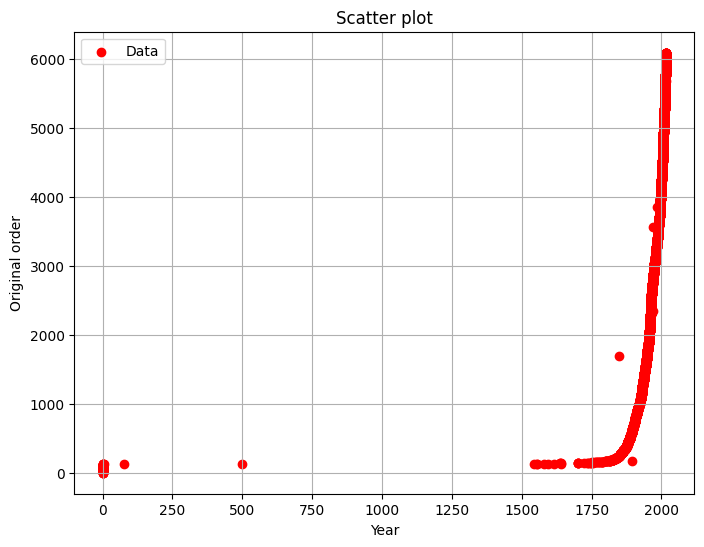

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(shark_attacks_df['Year'], shark_attacks_df['original order'], marker='o', color='r', label='Data')
plt.xlabel('Year')
plt.ylabel('Original order')
plt.title('Scatter plot')
plt.legend()
plt.grid(True)
plt.show()

## **Association rules**

In [24]:
# The association rules algorithm requires no missing values
# so for this step only we replace them with a placeholder on a copy of the dataset

run_algorithm = False

if run_algorithm:
    SHARK_ATTACKS_AR = shark_attacks_df.copy()
    SHARK_ATTACKS_AR.fillna('Unknown', inplace=True)

    transactions = []
    for i in range(len(SHARK_ATTACKS_AR)):
        transactions.append([f'{col}: {SHARK_ATTACKS_AR.values[i, j]}' for j, col in enumerate(SHARK_ATTACKS_AR.columns)])

    encoder = TransactionEncoder()
    encoder_ary = encoder.fit(transactions).transform(transactions)

    df_encoded = pd.DataFrame(encoder_ary, columns=encoder.columns_)
    frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)

    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

    useful_rules = rules[
        ~rules['antecedents'].astype(str).str.contains('Unknown') &
        ~rules['consequents'].astype(str).str.contains('Unknown')
    ]

    print(useful_rules.sort_values(by='lift', ascending=False))

## **Full data profiling with automated tools**
Generating a full profiling report with Y-DataProfiling library.

In [25]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [26]:
PROFILING_REPORT = ProfileReport(shark_attacks_df, title="Profiling Report")
PROFILING_REPORT

Output hidden; open in https://colab.research.google.com to view.

From the Profiling alone it can be proved that the dataset shows a high amount of Data Quality issues including:
*   Features 'Case Number', 'Case Number.1' and 'Case Number.2' being basically the same column repeated three times (with some exceptions for certain rows as shown above)
*   Features 'href' and 'href formula' containing the same information
*   'Name' has ≈3.4% missing values
*   'Area' has ≈6.8% missing values
*   'Location' has ≈8.4% missing values
*   'Activity' has ≈8.8% missing values
*   'Sex' has ≈9.5% missing values
*   'Age' has ≈44.7% missing values
*   'Species' has ≈49.2% missing values
*   'Time' has ≈53.3% missing values
*   'Year' has 124 (≈2%) zeroes
*   Trailing spaces in feature names: 'Sex ' and 'Species '
*   Misspellings and inconsistencies in 'Sex' values: 'M', 'F', 'female', 'M ', and 'N'
*   Misspellings and inconsistencies in 'Fatal (Y/N)': 'Y', 'N', 'UNKNOWN', ' N', and even '2017'
*   others


## **Data quality assessment**
Assessment of the following:
* Completeness
* Syntactic accuracy (the syntax of some of the columns can be inferred considering the context of the dataset)
* Consistency
* Uniqueness at column level
* Distinctness at column level
* Constancy at column level

**Completeness**

In [27]:
COMPLETENESS_BEFORE = shark_attacks_df.count().sum() / (ROWS * COLUMNS)    # Non-null cells / All cells
print(f'COMPLETENESS: {COMPLETENESS_BEFORE:.2%}')

COMPLETENESS: 91.54%


**Syntactic Accuracy**  
Column-wise syntactic accuracy calculation can be done in some cases shown below.

In [28]:
# 'Case Number' 'Case Number.1' and 'Case Number.2' features
# Assuming the format of YYYY.MM.DD(.[a-z])*  or ND-XXXX are the correct ones

regex_case_number = r'^\d{4}\.\d{2}\.\d{2}(\.[a-zA-Z])?$|^ND-\d{4}$'
correct_values_case_number_feature = shark_attacks_df['Case Number'].str.match(regex_case_number, na=False).sum()
correct_values_case_number1_feature = shark_attacks_df['Case Number.1'].str.match(regex_case_number, na=False).sum()
correct_values_case_number2_feature = shark_attacks_df['Case Number.2'].str.match(regex_case_number, na=False).sum()
accuracy_case_number_feature = correct_values_case_number_feature / column_stats['Case Number']['Count']
accuracy_case_number1_feature = correct_values_case_number1_feature / column_stats['Case Number.1']['Count']
accuracy_case_number2_feature = correct_values_case_number2_feature / column_stats['Case Number.2']['Count']

print(f'ACCURACY FOR "CASE NUMBER" FEATURE: {accuracy_case_number_feature:.2%}')
print(f'ACCURACY FOR "CASE NUMBER.1" FEATURE: {accuracy_case_number1_feature:.2%}')
print(f'ACCURACY FOR "CASE NUMBER.2" FEATURE: {accuracy_case_number2_feature:.2%}')

ACCURACY FOR "CASE NUMBER" FEATURE: 97.42%
ACCURACY FOR "CASE NUMBER.1" FEATURE: 97.42%
ACCURACY FOR "CASE NUMBER.2" FEATURE: 97.44%


In [29]:
# 'Age' feature
# This feature indicates the age of the victim of the shark attack
# For this reason we assume only integer values in between 0-150

def is_valid_age(x):
    try:
        val = int(x)
        return 0 <= val <= 150
    except:
        return False

correct_values_age_feature = shark_attacks_df['Age'].apply(is_valid_age).sum()
accuracy_age_feature = correct_values_age_feature / column_stats['Age']['Count']

print(f'ACCURACY FOR "AGE" FEATURE: {accuracy_age_feature:.2%}')

ACCURACY FOR "AGE" FEATURE: 97.03%


In [30]:
# 'Sex' feature
# This feature allows only two valid options: 'M' or 'F',
# however more appear in the dataset

SEX_DOMAIN = ['M', 'F']

correct_values_sex_feature = shark_attacks_df['Sex '].isin(SEX_DOMAIN).sum()
accuracy_sex_feature = correct_values_sex_feature / column_stats['Sex ']['Count']

print(f'ACCURACY FOR "SEX" FEATURE: {accuracy_sex_feature:.2%}')

ACCURACY FOR "SEX" FEATURE: 99.91%


In [31]:
# 'Fatal (Y/N)' feature
# This feature clearly states its valid domain in its name
# Either Y for true, or N for false

FATAL_DOMAIN = ['Y', 'N']

correct_values_fatal_feature = shark_attacks_df['Fatal (Y/N)'].isin(FATAL_DOMAIN).sum()
accuracy_fatal_feature = correct_values_fatal_feature / column_stats['Fatal (Y/N)']['Count']

print(f'ACCURACY FOR "FATAL" FEATURE: {accuracy_fatal_feature:.2%}')

ACCURACY FOR "FATAL" FEATURE: 98.24%


**Semantic Accuracy**   
Since only this dataset is provided, without an external ground truth, this kind of analysis is not feasible.

**Timeliness**  
The dataset has obvious historical data, but does not provide timestamps, thus this kind of analysis is not feasible.

**Consistency**     
Some minor integrity constraints on a small set of features can be performed.

In [32]:
# 'Case Number', 'Case Number.1' and 'Case Number.2' features
# Rule1: Case Number == Case Number.1 == Case Number.2

rule1_sat_mask = (shark_attacks_df['Case Number'] == shark_attacks_df['Case Number.1']) & \
                 (shark_attacks_df['Case Number'] == shark_attacks_df['Case Number.2'])

rule1_sat = rule1_sat_mask.sum()

CONSISTENCY_CASE_NUMS = rule1_sat / ROWS    # These columns have no missing values => can use ROWS as count
print(f'CONSISTENCY FOR RULE 1: {CONSISTENCY_CASE_NUMS:.2%}')

CONSISTENCY FOR RULE 1: 99.75%


In [33]:
# If 'FATAL' is in the 'Injury' feature, then the 'Fatal (Y/N)' feature
# must be set to Y
# Rule2: 'fatal|died|death' -> Y

rule2_premise_mask = shark_attacks_df['Injury'].str.contains('fatal|died|death', na=False, case=False)
rule2_consistent_mask = (rule2_premise_mask) & (shark_attacks_df['Fatal (Y/N)'].str.strip().str.upper() == 'Y')

applicable_count = rule2_premise_mask.sum()

CONSISTENCY_FATAL = rule2_consistent_mask.sum() / applicable_count
print(f'CONSISTENCY FOR RULE 2: {CONSISTENCY_FATAL:.2%}')

CONSISTENCY FOR RULE 2: 98.11%


In [34]:
# The year of 'Date' must match the year in 'Year'
# Rule3: 'Date'.year == 'Year'

date_converted = pd.to_datetime(shark_attacks_df['Date'], errors='coerce')

rule3_premise_mask = date_converted.notnull()
rule3_consistent_mask = (rule3_premise_mask) & (date_converted.dt.year == shark_attacks_df['Year'])

applicable_count = rule3_premise_mask.sum()

CONSISTENCY_DATE_YEAR = rule3_consistent_mask.sum() / applicable_count
print(f'CONSISTENCY FOR RULE 3: {CONSISTENCY_DATE_YEAR:.2%}')

CONSISTENCY FOR RULE 3: 86.75%


In [35]:
# Sometimes 'Name' contains 'male' or 'female'
# Rule4 and 5: 'Name' contains 'male' -> 'Sex'=='M' and 'Name' contains 'female' -> 'Sex'=='F'

rule4_premise_mask = shark_attacks_df['Name'].str.strip().str.lower().str.contains(r'\bmale\b', na=False, case=False, regex=True)
rule4_consistent_mask = (rule4_premise_mask) & (shark_attacks_df['Sex '] == 'M')

rule5_premise_mask = shark_attacks_df['Name'].str.strip().str.lower().str.contains(r'\bfemale\b', na=False, case=False, regex=True)
rule5_consistent_mask = (rule5_premise_mask) & (shark_attacks_df['Sex '] == 'F')

applicable_count_rule4 = rule4_premise_mask.sum()
applicable_count_rule5 = rule5_premise_mask.sum()

CONSISTENCY_MALE_NAME = rule4_consistent_mask.sum() / applicable_count_rule4
CONSISTENCY_FEMALE_NAME = rule5_consistent_mask.sum() / applicable_count_rule5

print(f'CONSISTENCY FOR RULE 4: {CONSISTENCY_MALE_NAME:.2%}')
print(f'CONSISTENCY FOR RULE 5: {CONSISTENCY_FEMALE_NAME:.2%}')

CONSISTENCY FOR RULE 4: 98.01%
CONSISTENCY FOR RULE 5: 95.54%


**Column-level uniqueness, distinctness and constancy evaluation**

In [36]:
for col in shark_attacks_df.columns:
    print('='*100)
    print(f'{col}')
    print()
    uniqueness = column_stats[col]['Distinct'] / ROWS
    distinctness = column_stats[col]['Distinct'] / column_stats[col]['Count']
    constancy = column_stats[col]['MaxCount'] / column_stats[col]['Count']
    print(f'UNIQUENESS: {uniqueness:.2%}')
    print(f'DISTINCTNESS: {distinctness:.2%}')
    print(f'CONSTANCY: {constancy:.2%}')

Case Number

UNIQUENESS: 99.74%
DISTINCTNESS: 99.74%
CONSTANCY: 0.03%
Date

UNIQUENESS: 85.28%
DISTINCTNESS: 85.28%
CONSTANCY: 0.18%
Year

UNIQUENESS: 3.94%
DISTINCTNESS: 3.94%
CONSTANCY: 2.31%
Type

UNIQUENESS: 0.10%
DISTINCTNESS: 0.10%
CONSTANCY: 73.33%
Country

UNIQUENESS: 3.35%
DISTINCTNESS: 3.37%
CONSTANCY: 35.71%
Area

UNIQUENESS: 13.11%
DISTINCTNESS: 14.06%
CONSTANCY: 17.86%
Location

UNIQUENESS: 65.38%
DISTINCTNESS: 71.36%
CONSTANCY: 2.90%
Activity

UNIQUENESS: 24.65%
DISTINCTNESS: 27.02%
CONSTANCY: 16.75%
Name

UNIQUENESS: 83.46%
DISTINCTNESS: 86.38%
CONSTANCY: 8.59%
Sex 

UNIQUENESS: 0.10%
DISTINCTNESS: 0.11%
CONSTANCY: 88.93%
Age

UNIQUENESS: 2.46%
DISTINCTNESS: 4.45%
CONSTANCY: 4.51%
Injury

UNIQUENESS: 59.81%
DISTINCTNESS: 60.09%
CONSTANCY: 12.30%
Fatal (Y/N)

UNIQUENESS: 0.15%
DISTINCTNESS: 0.15%
CONSTANCY: 72.41%
Time

UNIQUENESS: 5.89%
DISTINCTNESS: 12.61%
CONSTANCY: 6.36%
Species 

UNIQUENESS: 25.48%
DISTINCTNESS: 50.21%
CONSTANCY: 5.30%
Investigator or Source

UNIQUEN

## **Data transformations**

#### Renaming columns

In [37]:
new_names = {
    'Case Number': 'case_number_2',  # The original 'Case Number.2' differs only by 2 values from 'Case Number' and is more accurate in those 2 values
    'Case Number.1': 'case_number_1',
    'Case Number.2': 'case_number',
    'Date': 'date',
    'Year': 'year',
    'Type': 'type',
    'Country': 'country',
    'Area': 'area',
    'Location': 'location',
    'Activity': 'activity',
    'Name': 'name',
    'Sex ': 'sex',
    'Age': 'age',
    'Injury': 'injury',
    'Fatal (Y/N)': 'fatal',
    'Time': 'time',
    'Species ': 'species',
    'Investigator or Source': 'source',
    'pdf': 'pdf',
    'href formula': 'href_formula',
    'href': 'href',
    'original order': 'original_order'
}

shark_attacks_df = shark_attacks_df.rename(columns=new_names)

#### Dropping features

Dropping 'age', 'time' and 'species' since they have **≥44% missing values**, which cannot be imputed.

In [38]:
shark_attacks_df.drop(columns=['age', 'time', 'species'], inplace=True)
shark_attacks_df.columns

Index(['case_number_2', 'date', 'year', 'type', 'country', 'area', 'location',
       'activity', 'name', 'sex', 'injury', 'fatal', 'source', 'pdf',
       'href_formula', 'href', 'case_number_1', 'case_number',
       'original_order'],
      dtype='object')

Dropping 'case_number_1' and 'case_number_2' since they are mainly **duplicates** of 'case_number'. When they differ, the values are in a wrong format or contain wrong dates.

In [39]:
shark_attacks_df.drop(columns=['case_number_1', 'case_number_2'], inplace=True)
shark_attacks_df.columns

Index(['date', 'year', 'type', 'country', 'area', 'location', 'activity',
       'name', 'sex', 'injury', 'fatal', 'source', 'pdf', 'href_formula',
       'href', 'case_number', 'original_order'],
      dtype='object')

Dropping 'original_order' since it has a **high correlation** with 'year' (outliers (year=0) excluded)

In [40]:
shark_attacks_df.drop(columns=['original_order'], inplace=True)
shark_attacks_df.columns

Index(['date', 'year', 'type', 'country', 'area', 'location', 'activity',
       'name', 'sex', 'injury', 'fatal', 'source', 'pdf', 'href_formula',
       'href', 'case_number'],
      dtype='object')

Dropping 'href and 'href_formula'. As seen in the data exploration step, 'href' is either a duplicate of contains values that are inconsistent with 'pdf' and 'href_formula'. Either 'pdf' or 'href_formula' could be dropped.  Here we choose to drop the latter since it can be easily reconstructed from the former and it requires more memory space for storage purposes.

Row 906 does not contain a .pdf filename, however it can be recovered from the 'href' column, before dropping it.

In [41]:
# Fix pdf value for row 906 by extracting the filename from the href column
href_value = shark_attacks_df.at[906, 'href']
print(f'Row 906 "href" value: {href_value}')

if pd.notna(href_value):
    # Extract everything after the last '/'
    pdf_filename = href_value.split('/')[-1]
    print(f'Extracted filename: {pdf_filename}')
    shark_attacks_df.at[906, 'pdf'] = pdf_filename

# Verify the change
shark_attacks_df.loc[[906], ['name', 'pdf', 'href']]

Row 906 "href" value: http://sharkattackfile.net/spreadsheets/pdf_directory/2010.02.01-Ward.pdf
Extracted filename: 2010.02.01-Ward.pdf


,name,pdf,href
906,Lydia Ward,2010.02.01-Ward.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...


In [42]:
shark_attacks_df.drop(columns=['href', 'href_formula'], inplace=True)
shark_attacks_df.columns

Index(['date', 'year', 'type', 'country', 'area', 'location', 'activity',
       'name', 'sex', 'injury', 'fatal', 'source', 'pdf', 'case_number'],
      dtype='object')

Dropping 'location' feature since it requires manually cleaning each row one by one, and the dataset already contains 'country' and 'area' as geographical features.

In [43]:
shark_attacks_df.drop(columns=['location'], inplace=True)
shark_attacks_df.columns

Index(['date', 'year', 'type', 'country', 'area', 'activity', 'name', 'sex',
       'injury', 'fatal', 'source', 'pdf', 'case_number'],
      dtype='object')

#### Standardization

Standardizing 'case_number' feature

In [44]:
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.strip().str.lower()

In [45]:
# remove double full stop
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.replace(r'\.\.', '.', regex=True)

# fix minor inconsistencies
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.replace(r'&\s\w', '', regex=True)
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.replace('/', '.', regex=False)
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.replace('-', '.', regex=False)
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.replace(' ', '.', regex=False)

# to match the 'pdf' format
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.replace('nd.', 'nd-', regex=False)

# remove final '.'
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.rstrip('.')

# final strip
shark_attacks_df['case_number'] = shark_attacks_df['case_number'].str.strip()

# remove the B.C. years cases (case_number starts with 0.)
shark_attacks_df = shark_attacks_df[~shark_attacks_df['case_number'].str.startswith('0.', na=False)]

Standardizing 'date' feature into the YYYY-MM-DD format

In [46]:
# Stripping all values
shark_attacks_df['date'] = shark_attacks_df['date'].str.lower().str.strip()

# Remove punctuation from front or end of the string
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'^\W+|\W+$', '', regex=True)

# Remove words such as season names, 'mid', 'ca.', 'circa', 'before', 'after', 'reported'
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'\b(spring|summer|autumn|fall|winter)\b', '', regex=True)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'\b(mid|ca\.\s*|circa|before|after|reported|early|late|of|in)\b', '', regex=True)

# Make month strings compatible with the %b format
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('sept', 'sep', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('april', 'apr', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('june', 'jun', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('jun ', 'jun-', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('jut', 'jul', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('march', 'mar', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('may ', 'may-', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('sep-t', 'sep-1', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('0feb', '-feb', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('- jan', '-jan', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('^0-jan', '10-jan', regex=True)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('jan- ', 'jan-', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('-ap-', '-apr-', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('-decp', '-dec-', regex=False)
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace('october ', 'oct-', regex=False)

shark_attacks_df['date'] = shark_attacks_df['date'].str.extract(r'(\d{2}-[a-z]{3}-\d{4})', expand=False).fillna(shark_attacks_df['date'])
shark_attacks_df['date'] = shark_attacks_df['date'].str.extract(r'(\d{2}-[a-z]{3} \d{4})', expand=False).fillna(shark_attacks_df['date'])

# Remove trailing .[a-z]
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'\.\w+$', '', regex=True)

# Remove trailing 's'
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r's+$', '', regex=True)

# Stripping all values
shark_attacks_df['date'] = shark_attacks_df['date'].str.strip()

# Convert from YYYY-YY to YYYY
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%Y-%y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y').fillna(dates_subset)

# Convert from YYYY-YYYY to YYYY
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'^(\d{4})-\d{4}$', r'\1', regex=True)

# Convert from YYYY/YYYY to YYYY
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'^(\d{4})/\d{4}$', r'\1', regex=True)

# Convert from YYYY - YYYY to YYYY
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'^(\d{4})\s-\s\d{4}$', r'\1', regex=True)

# Convert from Mon-DD-YYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%b-%d-%Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from DD-Mon-YYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%d-%b-%Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from DD-Mon--YYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%d-%b--%Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from DD Mon-YYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%d %b-%Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from DD-Mon YYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%d-%b %Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from MM-DD-YYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%m-%d-%Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from YYYY.MM.DD to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%Y.%m.%d', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from DDMM-YYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%d%m-%Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

# Convert from DDMMYYYY to YYYY-MM-DD
dates_subset = shark_attacks_df['date']
parsed_dates = pd.to_datetime(dates_subset, format='%d%b%%Y', errors='coerce')
shark_attacks_df['date'] = parsed_dates.dt.strftime('%Y-%m-%d').fillna(dates_subset)

In [47]:
# Map lowercased month names to numeric strings
month_map = {
    'jan': '01', 'feb': '02', 'mar': '03', 'apr': '04',
    'may': '05', 'jun': '06', 'jul': '07', 'aug': '08',
    'sep': '09', 'oct': '10', 'nov': '11', 'dec': '12'
}

# Handle 'mon-YYYY' cases (e.g., 'jul-2008' -> '2008-07-00')
for mon, num in month_map.items():
    shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(rf'^{mon}-(\d{{4}})$', rf'\1-{num}-00', regex=True)

# Handle 'YYYY.MM' cases (e.g., '2008.01' -> '2008-01-00')
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'^(\d{4})\.(\d{2})$', r'\1-\2-00', regex=True)

# Handle 'YYYY' only cases (e.g., '2008' -> '2008-00-00')
shark_attacks_df['date'] = shark_attacks_df['date'].str.replace(r'^(\d{4})$', r'\1-00-00', regex=True)

# Handle remaining messy text rows (e.g., "last incident 1994 hong kong")
# We only want to extract the year if the string is NOT already in a structured format (YYYY-MM-DD)
is_structured = shark_attacks_df['date'].str.match(r'^\d{4}-\d{2}-\d{2}$', na=False)
messy_mask = (~is_structured) & (shark_attacks_df['date'].notna())

# For messy rows, extract the first 4-digit sequence and format as YYYY-00-00
years_extracted = shark_attacks_df.loc[messy_mask, 'date'].str.extract(r'(\d{4})', expand=False)
shark_attacks_df.loc[messy_mask, 'date'] = years_extracted.apply(lambda x: f"{x}-00-00" if pd.notna(x) else np.nan)

# Cleanup remaining noise that doesn't fit a YYYY format
# (e.g., "world war ii" or "no date" without a year)
shark_attacks_df.loc[~shark_attacks_df['date'].str.contains(r'\d{4}', na=False), 'date'] = np.nan

# Ensure B.C. dates (like '214 b') are handled.
shark_attacks_df.loc[shark_attacks_df['date'].str.contains(' b', na=False), 'date'] = np.nan

In [48]:
#Add the columns true_month and true_day to remember which pieces of the dates are the original ones and which ones have been added during the conversion
shark_attacks_df['true_month'] = shark_attacks_df['date'].astype(str).str[5:7] != '00'
shark_attacks_df['true_day'] = shark_attacks_df['date'].astype(str).str[8:10] != '00'

In [49]:
#function to correctly convert dates to datetime
def parse_date_with_placeholders(row):
    date_str = str(row['date'])
    year = date_str[:4]
    month = date_str[5:7]
    day = date_str[8:10]

    if not row['true_month']: # month was '00'
        return pd.to_datetime(f"{year}-01-01", errors='coerce')
    elif not row['true_day']: # day was '00', but month was valid
        return pd.to_datetime(f"{year}-{month}-01", errors='coerce')
    else: # fully specified date
        return pd.to_datetime(date_str, errors='coerce')

shark_attacks_df['date'] = shark_attacks_df.apply(parse_date_with_placeholders, axis=1)

Standardizing 'type' feature

In [50]:
shark_attacks_df['type'].unique()

array(['Unprovoked', 'Provoked', nan, 'Invalid', 'Boat', 'Sea Disaster',
       'Boating'], dtype=object)

In [51]:
# Basic cleaning: Lowercase and strip
shark_attacks_df['type'] = shark_attacks_df['type'].str.lower().str.strip()

# Merge synonyms (Boat -> Boating)
# 'Boating' is the most common format in the original data
shark_attacks_df['type'] = shark_attacks_df['type'].replace('boat', 'boating')

In [52]:
shark_attacks_df['type'].unique()

array(['unprovoked', 'provoked', nan, 'invalid', 'boating',
       'sea disaster'], dtype=object)

Standardizing 'country' feature

In [53]:
shark_attacks_df['country'].unique()

array(['AUSTRALIA', 'USA', 'UNITED KINGDOM', 'BAHAMAS',
       'UNITED ARAB EMIRATES', 'MEXICO', 'SOUTH AFRICA', 'REUNION',
       'NEW ZEALAND', 'ST HELENA, British overseas territory', 'BRAZIL',
       'INDONESIA', 'England', 'NEW CALEDONIA', 'SPAIN', 'CHINA', 'JAPAN',
       'COLUMBIA', 'EGYPT', 'FRENCH POLYNESIA', 'CAPE VERDE', 'Fiji',
       'DOMINICAN REPUBLIC', 'CAYMAN ISLANDS', 'ARUBA', 'ECUADOR',
       'MOZAMBIQUE', 'THAILAND', 'FIJI', 'PUERTO RICO', 'ITALY',
       'ATLANTIC OCEAN', 'GREECE', 'MAURITIUS', nan, 'ST. MARTIN',
       'FRANCE', 'PAPUA NEW GUINEA', 'TRINIDAD & TOBAGO', 'KIRIBATI',
       'ISRAEL', 'DIEGO GARCIA', 'TAIWAN', 'JAMAICA',
       'PALESTINIAN TERRITORIES', 'GUAM', 'SEYCHELLES', 'BELIZE',
       'PHILIPPINES', 'NIGERIA', 'TONGA', 'SCOTLAND', 'CANADA', 'CROATIA',
       'SAUDI ARABIA', 'CHILE', 'ANTIGUA', 'KENYA', 'RUSSIA',
       'TURKS & CAICOS', 'COSTA RICA', 'MALAYSIA',
       'UNITED ARAB EMIRATES (UAE)', 'SAMOA', 'AZORES', 'SOLOMON ISLANDS',
      

In [54]:
# Strip
shark_attacks_df['country'] = shark_attacks_df['country'].str.strip()

# Upper-case everything
shark_attacks_df['country'] = shark_attacks_df['country'].str.upper()

# Choosing the first option, when two are available
shark_attacks_df['country'] = shark_attacks_df['country'].str.split('/').str[0].str.strip()

# Remove acronym after full name, requires stripping afterwards
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'\s*\([^)]*\)', '', regex=True)

# Remove trailing '?'
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'\?$', '', regex=True)

# Replace ST with full word
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'\bST\.?\b', 'SAINT', regex=True)

# Clean case with Between two countries
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'BETWEEN\s+(.*?)\s+&\s+(.*)', r'\1', regex=True)

# Replace '&' with AND
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'&', 'AND', regex=True)

# Replace CEYLON with SRI LANKA
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'CEYLON', 'SRI LANKA', regex=True)

# Remove '-'
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'-', ' ', regex=True)

# Remove any punctuation
shark_attacks_df['country'] = shark_attacks_df['country'].str.replace(r'[^\w\s]', '', regex=True)

# Strip
shark_attacks_df['country'] = shark_attacks_df['country'].str.strip()

In [55]:
country_map = {
    'JAVA': 'INDONESIA',
    'SAINT MARTIN': 'SINT MAARTEN',
    'SAINT MAARTIN': 'SINT MAARTEN',
    'BAY OF BENGAL': 'INDIAN OCEAN',
    'BRITISH ISLES': 'UNITED KINGDOM',
    'BRITISH NEW GUINEA': 'PAPUA NEW GUINEA',
    'BRITISH VIRGIN ISLANDS': 'VIRGIN ISLANDS',
    'BURMA': 'MYANMAR',
    'COLUMBIA': 'COLOMBIA',
    'CRETE': 'GREECE',
    'GRAND CAYMAN': 'CAYMAN ISLANDS',
    'SAN DOMINGO': 'DOMINICAN REPUBLIC',
    'THE BALKANS': 'BALKANS'
}

shark_attacks_df['country'] = shark_attacks_df['country'].apply(lambda x: country_map[x] if x in country_map else x)

shark_attacks_df['country'] = shark_attacks_df['country'].str.lower().str.strip()

Fixing '�' in 'area'

In [56]:
mask = shark_attacks_df['area'].str.contains('�', na=False)
shark_attacks_df.loc[mask, 'area']

,area
307,d��tang-Sal�
467,d��tang-Sal�
720,Saman� Province
773,San Andr�s archipelago
1027,Maranh�o
1494,Conservat�ria District
1547,Saint-Beno�t
1985,L' Etang Sal�-les-Bains
2019,Saint-Beno�t
2215,Vava�u


In [57]:
# Fix Maranhao
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace('Maranh�o', 'Maranhao', regex=False)

# Fix Benoit
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace('Saint-Beno�t', 'Saint-Benoit', regex=False)

# Fix tang-Sal
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace('d��tang-Sal�', "L'Etang-Sale", regex=False)
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("L'Etang-Sal�", "L'Etang-Sale", regex=False)
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("L' Etang Sal�-les-Bains", "L'Etang-Sale", regex=False)

# Fix Côte d'Azur
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("C�te d'Azur", "Cote d'Azur", regex=False)

# Fix Cádiz
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("C�diz", "Cadiz", regex=False)

# Fix Limón Province
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Lim�n Province", "Limon Province", regex=False)

# Fix Colón Province
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Col�n Province", "Colon Province", regex=False)

# Fix Vava'u
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Vava�u", "Vava'u", regex=False)

# Fix Malaga
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("M�laga", "Malaga", regex=False)

# Fix Cortés
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Cort�s", "Cortes", regex=False)

# Fix Samana
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Saman� Province", "Samana Province", regex=False)

# Fix San Andreas
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("San Andr�s", "San Andres", regex=False)

# Fix Conservatoria District
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Conservat�ria District", "Conservatoria District", regex=False)

# Fix Bandar Mahshahr
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Bandar Ma�shur sea inlet", "Bandar Mahshahr", regex=False)

# Fix Khanh Hoa Province
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace("Kh�nh H�a Province", "Khanh Hoa", regex=False)

In [58]:
# Replace the rest of the weird char with °
shark_attacks_df['area'] = shark_attacks_df['area'].str.replace('�', '°', regex=False)

In [59]:
mask = shark_attacks_df['area'].str.contains('�', na=False)
shark_attacks_df.loc[mask, 'area']

,area


In [60]:
shark_attacks_df['area'] = shark_attacks_df['area'].str.strip().str.lower()

Standardizing all existing 'fatal' feature values to 'Y' (yes), 'N' (no) and np.nan (unknown)

In [61]:
shark_attacks_df['fatal'].unique()

array(['N', 'Y', nan, 'UNKNOWN', '2017', ' N', 'F', 'N ', '#VALUE!', 'n'],
      dtype=object)

In [62]:
fatal_values_map = {
    'N': 'n',
    'Y': 'y',
    'N ': 'n',
    ' N': 'n',
    'n': 'n',
    'F': np.nan,
    'UNKNOWN': np.nan,
    '2017': np.nan,
    '#VALUE!': np.nan,
    np.nan: np.nan
}

In [63]:
shark_attacks_df['fatal'] = shark_attacks_df['fatal'].apply(lambda x: fatal_values_map[x] if x in fatal_values_map else x)

In [64]:
shark_attacks_df['fatal'].unique()

array(['n', 'y', nan], dtype=object)

Standardizing all existing 'sex' feature values to 'M', 'F' and np.nan (unknown)

In [65]:
shark_attacks_df['sex'].unique()

array(['M', 'F', nan, 'M ', 'lli', 'N', '.'], dtype=object)

In [66]:
sex_values_map = {
    'M': 'm',
    'F': 'f',
    'M ': 'm',
    'N': 'm',               # we assume 'N' is 'M' misspelled since the two keys on the keyboard are extremely close
    'lli': 'm',             # the one instance with such 'sex' is 'Brian Kong' which, from the name, appears to be a male
    '.': np.nan,            # the one instance with such 'sex' has no info, so we chose np.nan
    np.nan: np.nan
}

In [67]:
shark_attacks_df['sex'] = shark_attacks_df['sex'].apply(lambda x: sex_values_map[x] if x in sex_values_map else x)

In [68]:
shark_attacks_df['sex'].unique()

array(['m', 'f', nan], dtype=object)

Standardizing 'activity' feature

In [69]:
shark_attacks_df['activity'] = shark_attacks_df['activity'].str.lower().str.strip()

# Category Mapping (Keyword-based)
activity_map = {
    'surfing': r'.*(surf|bodyboard|boogie|paddleboard|boarding).*',
    'swimming': r'.*(swim|bath|wad|float|tread).*',
    'fishing': r'.*(fish|spear|net|trawl|hook).*',
    'diving': r'.*(div|scuba|snorkel|pearl).*',
    'boating': r'.*(boat|kayak|canoe|row|sail|fell overboard|shipwreck).*',
}

def categorize_activity(text):
    if pd.isna(text):
        return np.nan
    for category, pattern in activity_map.items():
        if re.match(pattern, str(text)):
            return category
    return 'other'

shark_attacks_df['activity_standardized'] = shark_attacks_df['activity'].apply(categorize_activity)

# Handle "Hidden Nulls" in the original column
# For instance,  If the activity is just "unknown" or "nan", mark it as NaN
unknown_patterns = ['unknown', 'nan', '.', '?', ' ', 'not known']
shark_attacks_df.loc[shark_attacks_df['activity'].isin(unknown_patterns), 'activity_standardized'] = np.nan

In [70]:
# Empty strings replaced with nan
shark_attacks_df['activity'] = shark_attacks_df['activity'].replace('', np.nan)

In [71]:
shark_attacks_df['activity_standardized'].value_counts()

,count
activity_standardized,
swimming,1507
surfing,1363
fishing,1184
other,686
diving,573
boating,236


In [72]:
# Drop old 'activity'
shark_attacks_df.drop(columns=['activity'], inplace=True)

In [73]:
# Rename 'activity_standardized' to 'activity'
shark_attacks_df.rename(columns={'activity_standardized': 'activity'}, inplace=True)

Standardizing 'name' feature

In [74]:
# Standardize Whitespace (Crucial for matching)
# Replaces multiple spaces and non-breaking spaces (\xa0) with a single space
shark_attacks_df['name'] = shark_attacks_df['name'].str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()

# Identify strings that are not names at all
generic_descriptors = [
    'male', 'males', 'female', 'boy', 'girl', 'child', 'teen', 'youth', 'young',
    'adult', 'unknown', 'anonymous', 'no name', 'unidentified', 'refugee',
    'refugees', 'aboriginal', 'aborigines', 'indian', 'black', 'white',
    'tourist', 'bather', 'swimmer', 'diver', 'a citizen', 'a sailor',
    'a lifeguard', 'a native', 'a marine', 'a pilot', 'a student', 'a british citizen',
    'vietnamese fisherman', 'japanese fisherman', 'native boy', 'russian male', 'male a tourist from germany'
    'canadian teen', 'a spanish sailor', 'a visitor from spain', 'poachers', 'a spanish fisherman',
    'a male from miami', 'japanese female', 'a sport fisherman', 'a german tourist male', 'a surfer from port orange'
    'cabin cruiser owned by stefano catalani', 'severed human foot washed ashore in sneaker with velcro closures',
    'a south australian boy', 'a father six', 'several somali children', 'sydney woman', 'a senior aquarist', 'a student from belgrade',
    'male from tampa', 'black male', 'white male', 'a teenager', 'male a teen', 'filmer', 'indian male',
    'mexican male', 'a solomon islander', '	a fisherman', 'sailed with half survived explosion',
    'passenger in an automobile', 'a passenger', 'a youth', 'usaf -engine planes an hc- a hc- each with onboard collided in mid-air at low altitude and plunged into atlantic ocean',
    ''
]

# If the name is EXACTLY one of these, turn it into NaN
shark_attacks_df.loc[shark_attacks_df['name'].isin(generic_descriptors), 'name'] = np.nan

# Remove titles from remaining proper names
titles_to_strip = r'\b(dr|mr|mrs|ms|captain|ensign|officer|others|occupant[s]?|crew(man)?|of|the)\b[:\.]?'
shark_attacks_df['name'] = shark_attacks_df['name'].str.replace(titles_to_strip, '', regex=True).str.strip()

# Remove descriptions containing incident-related words
# If it mentions a boat or a body part, it's usually not a name
desc_junk = r'(boat|ferry|passengers|survivors|people|person|men|males|american|child|german|females|sportfish|russian|swiss|italian|indian|male|female|fisher|operator|sailor|young|youth|teen|japanese|tourist|german|spanish|women|body|passenger|teacher|remains|shark|dinghy|kayak|raft|scull|skiff|aircraft|refugee|incident|a belgian diver|males|diver|a dive guide|a danish tourist|a cambodian migrant worker|his dive buddy|a male from|male a tourist from)'
shark_attacks_df.loc[shark_attacks_df['name'].str.contains(desc_junk, na=False), 'name'] = np.nan

# Punctuation and Single Letters
# Remove everything except letters, spaces, and hyphens
shark_attacks_df['name'] = shark_attacks_df['name'].str.replace(r'[^a-z\s\-]', '', regex=True).str.strip()

# Remove starting '-'
shark_attacks_df['name'] = shark_attacks_df['name'].str.replace(r'^-', '', regex=True)

# If the string is empty or just 1 letter, it's a null
shark_attacks_df.loc[shark_attacks_df['name'].str.len() <= 1, 'name'] = np.nan

Standardizing 'injury' feature

In [75]:
shark_attacks_df['injury_raw'] = shark_attacks_df['injury'].str.lower().str.strip()

# Define patterns that mean "No Injury occurred" (Informative Data)
no_injury_patterns = r'no injury|uninjured|not bitten|no info|board bitten|boat bitten'

# Define patterns that mean "I don't know what happened" (Missing Data)
unknown_patterns = ['unknown', 'details unknown', 'no details', '?', '.', 'not recorded', 'nan', 'none']

def categorize_injury_pro(text):
    if pd.isna(text) or any(x == str(text) for x in unknown_patterns):
        return np.nan

    # Priority 1: FATAL (Highest severity)
    if re.search(r'fatal|death|died|killed|remains|not\s\w*\srecovered', text):
        return 'fatal'

    # Priority 2: MAJOR / AMPUTATION
    if re.search(r'amputat|severed|lost|mangled|crushed|lost (foot|leg|hand|arm)', text):
        return 'amputation'

    # Priority 3: BITE / LACERATIONS (Standard shark attack)
    if re.search(r'bite|bitten|lacerat|wound|gash|puncture|cut|incised', text):
        return 'lacerations'

    # Priority 4: MINOR / CONTACT
    if re.search(r'minor|abrasion|scratch|nip|bruise|graze', text):
        return 'minor injury'

    # Priority 5: NO INJURY
    if re.search(no_injury_patterns, text):
        return 'no injury'

    return 'unclassified'

shark_attacks_df['injury'] = shark_attacks_df['injury'].apply(categorize_injury_pro)

In [76]:
shark_attacks_df['injury'].value_counts()

,count
injury,
unclassified,3049
lacerations,2309
amputation,395
fatal,207
minor injury,74
no injury,27


Standardizing 'source' feature

In [77]:
shark_attacks_df['source'] = shark_attacks_df['source'].str.lower().str.strip()

In [78]:
# remove everything in parenthesis (if exists)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\([^)]*\)', '', regex=True)

In [79]:
# remove dates found
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\d{1,2}-\d{1,2}-\d{4}', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\d{1,2}.\d{1,2}.\d{4}', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\d{1,2},\d{1,2},\d{4}', '', regex=True)

# remove p.__ artifacts such as p.2A or p.B7
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'p{1,2}\.\s*\d+-\d+', '', regex=True) #removes p.117-123 or pp.125-126
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'p\.\s*\d+\w*', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'p\.\s*\w+\d*', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'p,\s*\d+', '', regex=True)

# remove common words
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('dated', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('citing the', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('citing', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('cites', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('cite', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('et.al', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('et al', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('et al.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('et. al', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('el al', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(', page', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('ed.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('dr.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('lt.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('col.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('mr.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('mrs.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('ms.', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\bdr', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\bmr', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\bmrs', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('[' , '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(']', '', regex=False)

In [80]:
# Replace delimiters
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('/', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(';', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(':', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('&', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('#', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('-', '', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(' , ', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(', ', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(' ,', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(',,', ',', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('\band', ',', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('\band\b', ',', regex=False)

# remove recurrent X,X,X artifact
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\d{1,2},\d{1,2},\d{1,2}', '', regex=True)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\d{1,2},\d{1,2},\d{1,2},\d{1,2}', '', regex=True)

# remove XXXX artifacts
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace(r'\d{4}', '', regex=True)

# Strip
shark_attacks_df['source'] = shark_attacks_df['source'].str.strip()

# remove final ',' or '.'
shark_attacks_df['source'] = shark_attacks_df['source'].str.rstrip(',')
shark_attacks_df['source'] = shark_attacks_df['source'].str.rstrip('.')

# remove starting ',' or '.'
shark_attacks_df['source'] = shark_attacks_df['source'].str.lstrip(',')
shark_attacks_df['source'] = shark_attacks_df['source'].str.lstrip('.')

# Strip
shark_attacks_df['source'] = shark_attacks_df['source'].str.strip()

In [81]:
# show all cases with weird char
mask = shark_attacks_df['source'].str.contains('�', na=False)
shark_attacks_df.loc[mask, 'source']

,source
167,les nouvelles cal�doniennes
168,les nouvelles cal�doniennes
281,polyn�sie 1�re
307,l'yonne r�publicaine
616,"a. brenneka,shark attack survivors,les nouvell..."
760,"v. boyer,le journal de l��le de la r�union"
871,g�ldahora
1103,"d. inggs,gletwyn rubidge�s spearfishing and fr..."
1126,les nouvelles cal�donie
1250,les nouvelles cal�doniennes


In [82]:
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('r�union', 'reunion', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('cal�doniennes', 'caledoniennes', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('cal�donie', 'caledoniennes', regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('d�aubrey', "d'aubrey", regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('r�publicaine', "republicaine", regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('polyn�sie 1�re', "polynesie premiere", regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('l��le', "l'ile", regex=False)
shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('g�ldahora', "goldahora", regex=False)


shark_attacks_df['source'] = shark_attacks_df['source'].str.replace('�', "'", regex=False)

In [83]:
shark_attacks_df[['date', 'source']]

,date,source
0,2017-06-11,wa today
1,2017-06-10,NaN
2,2017-06-10,daytona beach newsjournal
3,2017-06-07,"c. moore,gsaf"
4,2017-06-04,nine news
...,...,...
6089,1903-01-01,"h. taunton,n. bartlett"
6090,1903-01-01,"h. taunton,n. bartlett"
6091,1900-01-01,"f. schwartz,c. creswell,gsaf"
6092,1883-01-01,the sun


Standardizing 'pdf' feature

In [84]:
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.strip().str.lower()

In [85]:
# Replace all '_' with '-'
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace('_', '-', regex=False)

# Replace ' ' with ''
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace(' ', '', regex=False)

# Remove '
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace("'", '', regex=False)

In [86]:
# Removing file extension as it can be implicitly taken from the feature name 'pdf' and would waste 4B x 6000+ rows

# -pdf
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace('-pdf', '', regex=False)

# , pdf
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace(', pdf', '', regex=False)

# . pdf
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace('. pdf', '', regex=False)

# .pf
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace('.pf', '', regex=False)

# .pdf
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace('.pdf', '', regex=False)

# remove starting '.'
shark_attacks_df['pdf'] = shark_attacks_df['pdf'].str.replace(r'^\.', '', regex=True)

In [87]:
shark_attacks_df

,date,year,type,country,area,name,sex,injury,fatal,source,pdf,case_number,true_month,true_day,activity,injury_raw
0,2017-06-11,2017.0,unprovoked,australia,western australia,paul goff,m,lacerations,n,wa today,2017.06.11-goff,2017.06.11,True,True,surfing,"no injury, board bitten"
1,2017-06-10,2017.0,unprovoked,australia,victoria,NaN,f,unclassified,n,NaN,2017.06.10.b-flinders,2017.06.10.b,True,True,surfing,"no injury, knocke off board"
2,2017-06-10,2017.0,unprovoked,usa,florida,bryan brock,m,unclassified,n,daytona beach newsjournal,2017.06.10.a-brock,2017.06.10.a,True,True,surfing,laceration to left foot
3,2017-06-07,2017.0,unprovoked,united kingdom,south devon,rich thomson,m,lacerations,n,"c. moore,gsaf",2017.06.07.r-thomson,2017.06.07.r,True,True,surfing,"bruise to leg, cuts to hand sustained when he ..."
4,2017-06-04,2017.0,unprovoked,usa,florida,parker simpson,m,unclassified,n,nine news,2017.06.04-simpson,2017.06.04,True,True,fishing,laceration to shin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6089,1903-01-01,0.0,unprovoked,australia,western australia,NaN,m,unclassified,y,"h. taunton,n. bartlett",nd-0005-roebuckbay,nd-0005,False,False,diving,fatal
6090,1903-01-01,0.0,unprovoked,australia,western australia,ahmun,m,unclassified,y,"h. taunton,n. bartlett",nd-0004-ahmun,nd-0004,False,False,diving,fatal
6091,1900-01-01,0.0,unprovoked,usa,north carolina,NaN,m,unclassified,y,"f. schwartz,c. creswell,gsaf",nd-0003-ocracoke-1900-1905,nd-0003,False,False,swimming,fatal
6092,1883-01-01,0.0,unprovoked,panama,NaN,jules patterson,m,unclassified,y,the sun,nd-0002-julespatterson,nd-0002,False,False,NaN,fatal


#### Column reordering

In [88]:
new_order = ['case_number', 'date', 'year', 'true_month', 'true_day', 'type', 'country', 'area', 'activity', 'name', 'sex', 'injury', 'fatal', 'source', 'pdf']
shark_attacks_df = shark_attacks_df[new_order]
shark_attacks_df.columns

Index(['case_number', 'date', 'year', 'true_month', 'true_day', 'type',
       'country', 'area', 'activity', 'name', 'sex', 'injury', 'fatal',
       'source', 'pdf'],
      dtype='object')

## **Missing values handling**

In [89]:
#create a copy of the dataset to modify
copy = shark_attacks_df.copy()

<Axes: >

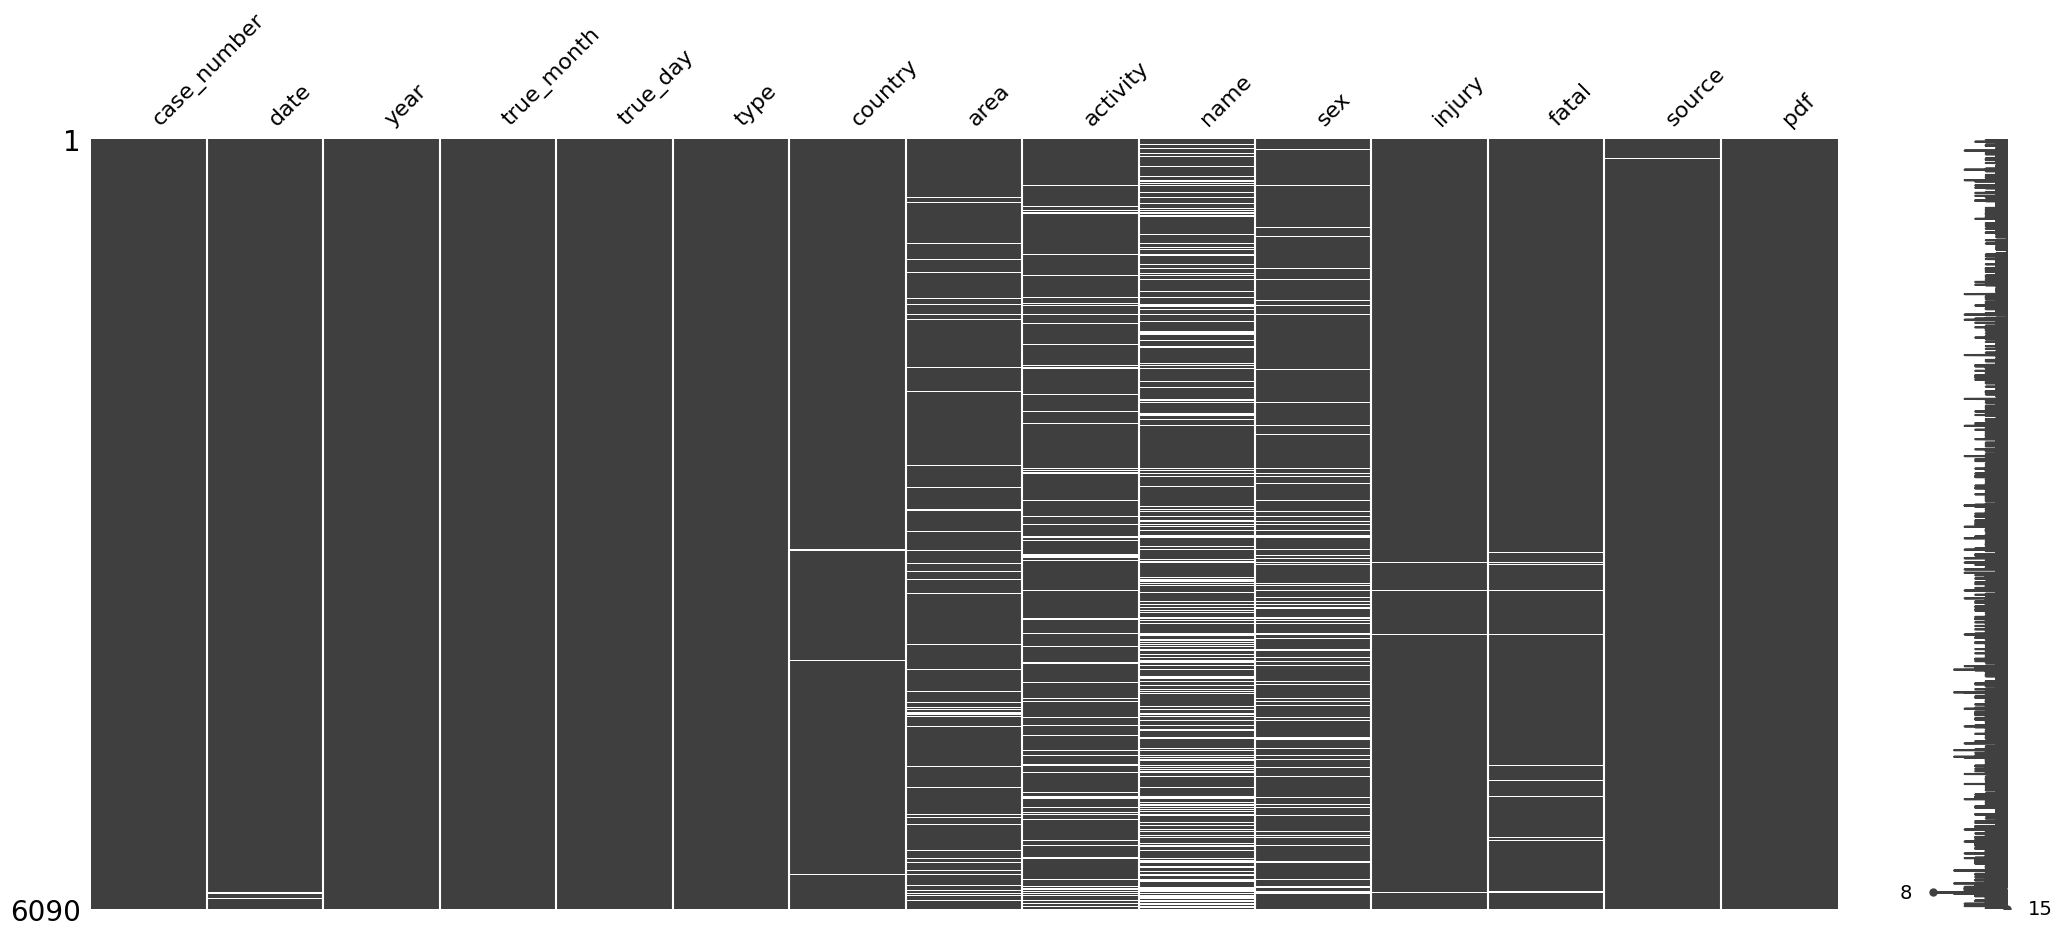

In [90]:
#show graphically the distribution of missing values
mno.matrix(copy)

In [91]:
#for each column show the number of missing values
copy.isnull().sum()

,0
case_number,0
date,21
year,2
true_month,0
true_day,0
type,4
country,45
area,412
activity,541
name,1559


#### Filling missing values

In [92]:
# DATE
null_date_mask = copy['date'].isnull()

#Set the date as 1st January of the year given by the year fields and set true_month and true_day to False
copy.loc[null_date_mask, 'date'] = pd.to_datetime(
    copy.loc[null_date_mask, 'year'].astype(int).astype(str) + '-01-01', errors='coerce'
)
copy.loc[null_date_mask, 'true_month'] = False
copy.loc[null_date_mask, 'true_day'] = False

# Drop rows where date is still null because out of datetime range
copy.drop(copy[copy['date'].isnull()].index, inplace=True)

In [93]:
# YEAR
null_year_mask = copy['year'].isnull()
# fill the column year taking it from the date field
copy.loc[null_year_mask, 'year'] = copy.loc[null_year_mask, 'date'].dt.year.astype(float)

In [94]:
# TYPE
null_type_mask = copy['type'].isnull()
#If the type of attack is null we can't impute it, so we put a standard 'unknown' value
copy.loc[null_type_mask, 'type'] = 'unknown'

In [95]:
# COUNTRY AND AREA
null_country_or_area_mask = copy['country'].isnull() | copy['area'].isnull()
null_country_valid_area_mask = copy['country'].isnull() & copy['area'].notna()
null_area_valid_country_mask = copy['area'].isnull() & copy['country'].notna()

#If area is null but country has a value we use that value also for the area
copy.loc[null_area_valid_country_mask, 'area'] = copy.loc[null_area_valid_country_mask, 'country']

#If country is null but area has a valid value, we impute the country using the mode between the other rows with the same area
area_country_map = copy.dropna(subset=['country']).groupby('area')['country'].apply(lambda x: x.mode()[0])
copy['country'] = copy['country'].fillna(copy['area'].map(area_country_map))

#if both country and area are null replace them with a standard 'unknown' value
null_country_mask = copy['country'].isnull()
null_area_mask = copy['area'].isnull()
copy.loc[null_country_mask, 'country'] = 'unknown'
copy.loc[null_area_mask, 'area'] = 'unknown'

In [96]:
# ACTIVITY
null_activity_mask = copy['activity'].isnull()
#If the activity is null we can't impute it, so we put a standard 'unknown' value
copy.loc[null_activity_mask, 'activity'] = 'unknown'

In [97]:
# NAME
null_name_mask = copy['name'].isnull()
#If the name is null we cannot impute it, so we put a standard 'unknown' value
copy.loc[null_name_mask, 'name'] = 'unknown'

In [98]:
# SEX
null_sex_mask = copy['sex'].isnull()

#We use the package gender_guesser to guess the sex from the name
d = gender.Detector(case_sensitive=False)

#define a function to find the sex for each name
def predict_sex(full_name):
    #since the name it is usually the first word of the field name, we extract it to predict the gender
    first_name = full_name.split(' ')[0]
    prediction = d.get_gender(first_name)

    # Map the output to our dataset's standard format
    if prediction == 'male' or prediction == 'mostly_male':
        return 'm'
    elif prediction == 'female' or prediction == 'mostly_female':
        return 'f'
    else:
        return 'u'

#Apply the function to the rows with missing sex
copy.loc[null_sex_mask, 'sex'] = copy.loc[null_sex_mask, 'name'].apply(predict_sex)

In [99]:
#FATAL and INJURY
#If both fatal and injury are null, we replace them with standard 'u' and 'unknown'
null_fatal_injury_mask = copy['fatal'].isnull() & copy['injury'].isnull()
copy.loc[null_fatal_injury_mask, 'fatal'] = 'u' #u stands for unknown
copy.loc[null_fatal_injury_mask, 'injury'] = 'unclassified'

#If fatal is 'y' AND injury is null we set injury to 'fatal'
fatal_y_and_injury_null_mask = (copy['fatal'] == 'y') & (copy['injury'].isnull())
copy.loc[fatal_y_and_injury_null_mask, 'injury'] = 'fatal'

#If fatal is 'n' AND injury is null we set injury to 'unclassified' since we don't know which is the exact type of injury
fatal_n_and_injury_null_mask = (copy['fatal'] == 'n') & (copy['injury'].isnull())
copy.loc[fatal_n_and_injury_null_mask, 'injury'] = 'unclassified'

#If injury is 'fatal' AND fatal is null we set fatal to 'y'
injury_f_and_fatal_null_mask = (copy['injury'] == 'fatal') & (copy['fatal'].isnull())
copy.loc[injury_f_and_fatal_null_mask, 'fatal'] = 'y'

#If injury is 'unclassified' AND fatal is null we set fatal to 'u'
injury_u_and_fatal_null_mask = (copy['injury'] == 'unclassified') & (copy['fatal'].isnull())
copy.loc[injury_u_and_fatal_null_mask, 'fatal'] = 'u'

#If injury is one of the other values AND fatal is null we set fatal to 'n'
remaining_fatal_null_mask = (copy['injury'] != 'fatal') & (copy['injury'] != 'unclassified') & (copy['fatal'].isnull())
copy.loc[remaining_fatal_null_mask, 'fatal'] = 'n'

In [100]:
# SOURCE
null_source_mask = copy['source'].isnull()
#If the source is null we can't impute it, so we put a standard 'unknown' value
copy.loc[null_source_mask, 'source'] = 'unknown'

In [101]:
copy.isnull().sum()

,0
case_number,0
date,0
year,0
true_month,0
true_day,0
type,0
country,0
area,0
activity,0
name,0


In [102]:
#save the changes made on the copy
shark_attacks_df = copy.copy()

## **Outlier Detection**
The only columns on which outlier detection makes sense are the columns date and year


In the column date we don't see relevant outliers

<Axes: ylabel='date'>

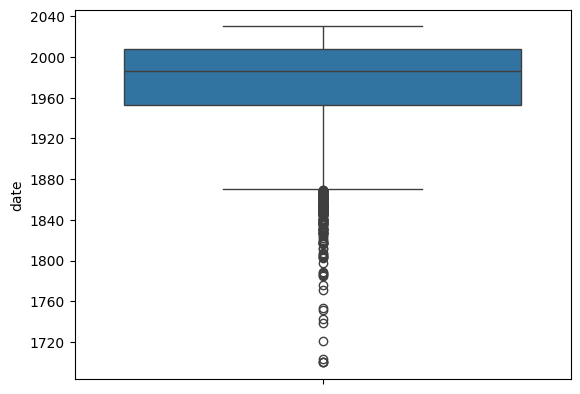

In [103]:
#plot dates distribution
sns.boxplot(shark_attacks_df['date'])

We see that there are many values set to 0, probably a default value

<Axes: ylabel='year'>

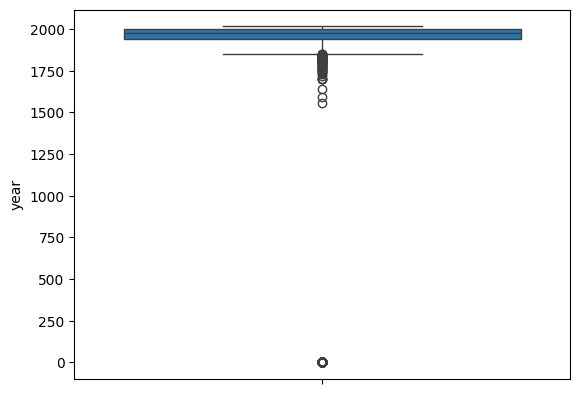

In [104]:
#plot years distribution
sns.boxplot(shark_attacks_df['year'])

In [105]:
#0 is probably a default value for the year field when the date is not complete. We correct those values taking the year field from the date
outliers_mask = shark_attacks_df['year'] == 0
shark_attacks_df.loc[outliers_mask, 'year'] = shark_attacks_df.loc[outliers_mask, 'date'].dt.year.astype(float)
shark_attacks_df[outliers_mask]

,case_number,date,year,true_month,true_day,type,country,area,activity,name,sex,injury,fatal,source,pdf
5974,nd-0153,1990-01-01,1990.0,False,False,unprovoked,kenya,mombasa,diving,conway plough jonathan higgs,m,lacerations,n,a.j. venter,nd-0153-plough-higgs
5975,nd-0152,2016-01-01,2016.0,False,False,unprovoked,kenya,mombasa,diving,hamisi njenga,m,unclassified,y,eadestination,nd-0152-kenya
5976,nd-0151,2009-10-01,2009.0,True,False,unprovoked,panama,bocas del toro province,swimming,unknown,m,unclassified,y,"c. mendieta,a. duarte",nd-0151-panama
5977,nd-0150,1934-01-01,1934.0,False,False,unprovoked,uruguay,rocha,swimming,unknown,u,lacerations,n,di candia,nd-0150-uruguay
5978,nd-0149,1934-01-01,1934.0,False,False,unprovoked,uruguay,rocha,swimming,maciello,m,unclassified,y,di candia,nd-0149-maciello
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6089,nd-0005,1903-01-01,1903.0,False,False,unprovoked,australia,western australia,diving,unknown,m,unclassified,y,"h. taunton,n. bartlett",nd-0005-roebuckbay
6090,nd-0004,1903-01-01,1903.0,False,False,unprovoked,australia,western australia,diving,ahmun,m,unclassified,y,"h. taunton,n. bartlett",nd-0004-ahmun
6091,nd-0003,1900-01-01,1900.0,False,False,unprovoked,usa,north carolina,swimming,unknown,m,unclassified,y,"f. schwartz,c. creswell,gsaf",nd-0003-ocracoke-1900-1905
6092,nd-0002,1883-01-01,1883.0,False,False,unprovoked,panama,panama,unknown,jules patterson,m,unclassified,y,the sun,nd-0002-julespatterson


<Axes: ylabel='year'>

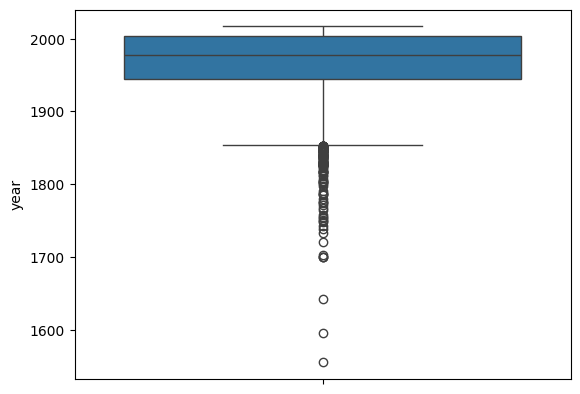

In [106]:
#plot years distribution to check that all the outliers have been fixed
sns.boxplot(shark_attacks_df['year'])

## **Duplicate Detection**


#### Exact matching

In [107]:
#looking for for exact duplicates, none are found
shark_attacks_df.duplicated().any()

np.False_

#### Record Linkage

**Find the candidate pairs**

In [108]:
#We define two criteria to find candidate pairs
#The first criterion is to apply sorted neighborhood on the date field
indexer1 = recordlinkage.index.SortedNeighbourhood(
        on='date', window=11 #the frequency of the most common date
)

#The first criterion is to apply blocking on the fields country and area
indexer2 = recordlinkage.Index()
indexer2.block('country', 'area')

candidate_links = indexer1.index(shark_attacks_df).union(indexer2.index(shark_attacks_df))
candidate_links

MultiIndex([(   1,    0),
            (   2,    0),
            (   2,    1),
            (   3,    0),
            (   3,    1),
            (   3,    2),
            (   4,    0),
            (   4,    1),
            (   4,    2),
            (   4,    3),
            ...
            (6093, 5862),
            (6093, 5863),
            (6093, 5864),
            (6093, 5865),
            (6093, 5866),
            (6093, 5867),
            (6093, 5868),
            (6093, 5870),
            (6093, 5873),
            (6093, 5918)],
           length=53378)

**Comparisons between candidate pairs**

In [109]:
copy = shark_attacks_df.copy()
compare_cl = recordlinkage.Compare()

#names will be compared using their soundex representation
copy['name'] = phonetic(copy['name'], 'soundex')
compare_cl.string('name', 'name', method='jarowinkler', threshold=0.9, label='name')

#Compare fields using string similarity
compare_cl.string('case_number', 'case_number', method='jarowinkler', threshold=0.9, label='case_number')
compare_cl.string('area', 'area', method='cosine', threshold=0.9, label='area')
compare_cl.string('source', 'source', method='cosine', threshold=0.9, label='source')
compare_cl.string('pdf', 'pdf', method='cosine', threshold=0.9, label='pdf')

#compare dates
compare_cl.date('date', 'date', label='date')

#Rows that should have exact matching
compare_cl.exact('year', 'year', label='year')
compare_cl.exact('country', 'country', label='country')
#categorical columns
compare_cl.exact('type', 'type', label='type')
compare_cl.exact('activity', 'activity', label='activity')
compare_cl.exact('sex', 'sex', label='sex')
compare_cl.exact('injury', 'injury', label='injury')
compare_cl.exact('fatal', 'fatal', label='fatal')

#compute the similarity score of each couple of rows
features = compare_cl.compute(candidate_links, copy)
features

name  case_number  area  source  pdf  date  year  country  type  \
1    0      0.0          1.0   0.0     0.0  0.0   0.0     1        1     1   
2    0      0.0          1.0   0.0     0.0  0.0   0.0     1        0     1   
     1      0.0          1.0   0.0     0.0  0.0   1.0     1        0     1   
3    0      0.0          0.0   0.0     0.0  0.0   0.0     1        0     1   
     1      0.0          1.0   0.0     0.0  0.0   0.0     1        0     1   
...         ...          ...   ...     ...  ...   ...   ...      ...   ...   
6093 5867   1.0          0.0   0.0     0.0  0.0   0.0     0        0     1   
     5868   0.0          0.0   0.0     0.0  0.0   0.0     0        0     1   
     5870   1.0          0.0   0.0     0.0  0.0   0.0     0        0     0   
     5873   0.0          0.0   0.0     0.0  0.0   0.0     0        0     1   
     5918   1.0          0.0   0.0     0.0  0.0   0.0     0        1     1   

           activity  sex  injury  fatal  
1    0            1    0       0      1  
2    0            1    1       0      1  
     1            1    0       1      1  
3    0            1    1       1      1  
     1            1    0       0      1  
...             ...  ...     ...    ...  
6093 5867         1    1       1      1  
     5868         0    1       1      1  
     5870         0    0       1      0  
     5873         1    1       1      1  
     5918         0    1       0      0  

[53378 rows x 13 columns]

In [110]:
features.describe()

,name,case_number,area,source,pdf,date,year,country,type,activity,sex,injury,fatal
count,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000,53378.000000
mean,0.099404,0.350069,0.101559,0.027165,0.000599,0.031371,0.555079,0.447713,0.536626,0.220072,0.686519,0.427648,0.620668
std,0.299207,0.476996,0.302070,0.162565,0.024478,0.172957,0.496962,0.497263,0.498661,0.414299,0.463912,0.494742,0.485225
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [111]:
#count the number of couples of similar, grouped by the similarity score
features.sum(axis=1).value_counts().sort_index(ascending=False)

,count
13.0,3
12.0,24
11.0,78
10.5,1
10.0,163
9.5,4
9.0,464
8.5,3
8.0,1196
7.5,9


In [112]:
#We decide that duplicates are rows with 11 or more as similarity score
matches = features[features.sum(axis=1) >= 11]
matches

name  case_number  area  source  pdf  date  year  country  type  \
75   74     1.0          1.0   1.0     1.0  0.0   0.0     1        1     1   
78   77     0.0          1.0   1.0     1.0  0.0   1.0     1        1     1   
79   77     1.0          1.0   1.0     1.0  0.0   1.0     1        1     1   
     78     0.0          1.0   1.0     1.0  0.0   1.0     1        1     1   
93   92     0.0          1.0   1.0     1.0  0.0   1.0     1        1     1   
...         ...          ...   ...     ...  ...   ...   ...      ...   ...   
6084 5792   1.0          0.0   1.0     1.0  0.0   1.0     1        1     1   
6086 6085   1.0          1.0   1.0     1.0  0.0   1.0     1        1     1   
6087 6085   1.0          1.0   1.0     1.0  0.0   1.0     1        1     1   
     6086   1.0          1.0   1.0     1.0  0.0   1.0     1        1     1   
6090 6089   0.0          1.0   1.0     1.0  0.0   1.0     1        1     1   

           activity  sex  injury  fatal  
75   74           1    1       1      1  
78   77           1    1       1      1  
79   77           1    1       1      1  
     78           1    1       1      1  
93   92           1    1       1      1  
...             ...  ...     ...    ...  
6084 5792         1    1       1      1  
6086 6085         1    1       1      1  
6087 6085         1    1       1      1  
     6086         1    1       1      1  
6090 6089         1    1       1      1  

[105 rows x 13 columns]

In [113]:
#we define a function to count the number of standard values of a row
def count_unknown(row):
  cont = 0

  for column in row.index:
    if row[column] == 'u' or row[column] == 'Unknown' or row[column] == 'unlcassified':
      cont = cont + 1

    if not row['true_month']:
      cont = cont + 1
    if not row['true_day']:
      cont = cont + 1

  return cont

In [114]:
indices_to_drop = set() # Use a set to store indices to drop

# For each pair identified as a potential match
for index_tuple, row in matches.iterrows():
  idx0 = index_tuple[0]
  idx1 = index_tuple[1]

  # Skip if one or both indexes have already been marked for dropping
  if idx0 in indices_to_drop or idx1 in indices_to_drop:
      continue

  # Compute unknown counts for both rows in the pair
  count_0 = count_unknown(shark_attacks_df.loc[idx0])
  count_1 = count_unknown(shark_attacks_df.loc[idx1])

  # Drop the row with more unknown values
  if count_0 > count_1:
    indices_to_drop.add(idx0)
  else:
    indices_to_drop.add(idx1)

print(f'{len(indices_to_drop)} rows will be dropped')

# Drop all identified duplicate rows
# Using errors='ignore' to avoid issues if an index was already dropped
shark_attacks_df.drop(list(indices_to_drop), inplace=True, errors='ignore')

91 rows will be dropped


## **Final Data Quality Assessment**


#### **Basic Profiling**

In [115]:
#number of rows
ROWS = shark_attacks_df.shape[0]
print(f'The dataset has {ROWS} rows.')

The dataset has 5980 rows.


In [116]:
#number and names of the columns
COLUMNS = shark_attacks_df.shape[1]
print(f'The dataset has {COLUMNS} columns.')
shark_attacks_df.columns

The dataset has 15 columns.


Index(['case_number', 'date', 'year', 'true_month', 'true_day', 'type',
       'country', 'area', 'activity', 'name', 'sex', 'injury', 'fatal',
       'source', 'pdf'],
      dtype='object')

In [117]:
#final types of the columns
shark_attacks_df.dtypes

,0
case_number,object
date,datetime64[ns]
year,float64
true_month,bool
true_day,bool
type,object
country,object
area,object
activity,object
name,object


#### **Single Column Analysis**

In [118]:
column_stats = {}

In [119]:
# Collecting column statistics
for col in shark_attacks_df.columns:
    column_stats[col] = {}

    column_stats[col]['Count'] = shark_attacks_df[col].count()
    column_stats[col]['Null'] = shark_attacks_df[col].isnull().sum()
    column_stats[col]['Distinct'] = shark_attacks_df[col].nunique()
    column_stats[col]['Duplicated'] = shark_attacks_df[col].duplicated().sum()
    column_stats[col]['MaxCount'] = max(shark_attacks_df[col].value_counts())

    print()
    print()
    print()
    print('='*100)
    print(f'Column: {col}')
    print('='*100)
    print(f'Non-null values: {column_stats[col]["Count"]}')
    print(f'Null values: {column_stats[col]["Null"]}')
    print(f'Null percentage: {(column_stats[col]['Null'] / ROWS * 100):.1f}%')
    print(f'Distinct values: {column_stats[col]["Distinct"]}')
    print(f'Duplicated values: {column_stats[col]["Duplicated"]}')
    print('-'*100)
    print(shark_attacks_df[col].value_counts())

    if shark_attacks_df[col].dtype in ['int64', 'float64']:
        print('-'*100)
        print(f'Min value: {shark_attacks_df[col].min()}')
        print(f'Max value: {shark_attacks_df[col].max()}')
        print(f'Mean value: {shark_attacks_df[col].mean()}')
        print(f'Median value: {shark_attacks_df[col].median()}')
        print(f'Standard deviation: {shark_attacks_df[col].std()}')




Column: case_number
Non-null values: 5980
Null values: 0
Null percentage: 0.0%
Distinct values: 5968
Duplicated values: 12
----------------------------------------------------------------------------------------------------
case_number
1915.07.06.a.r    2
1990.05.10        2
2006.09.02        2
2009.12.18        2
1966.12.26        2
                 ..
1998.10.04        1
1998.10.10        1
1998.10.18        1
1998.10.24        1
1998.08.30        1
Name: count, Length: 5968, dtype: int64



Column: date
Non-null values: 5980
Null values: 0
Null percentage: 0.0%
Distinct values: 5025
Duplicated values: 955
----------------------------------------------------------------------------------------------------
date
1905-05-10    11
1960-01-01     9
1905-04-25     8
1963-01-01     8
1958-01-01     8
              ..
1912-06-08     1
1896-01-01     1
1876-01-01     1
1908-01-01     1
1951-01-01     1
Name: count, Length: 5025, dtype: int64



Column: year
Non-null values: 5980
Null value

#### **Data Profiling with automated tools**

In [120]:
PROFILING_REPORT = ProfileReport(shark_attacks_df, title="Profiling Report")
PROFILING_REPORT

Output hidden; open in https://colab.research.google.com to view.

#### **Complete Data quality assessment**
Assessment of the following:
* Completeness
* Syntactic accuracy (the syntax of some of the columns can be inferred considering the context of the dataset)
* Consistency
* Uniqueness at column level
* Distinctness at column level
* Constancy at column level

**Completeness**

In [121]:
COMPLETENESS_AFTER = shark_attacks_df.count().sum() / (ROWS * COLUMNS)    # Non-null cells / All cells
print(f'COMPLETENESS: {COMPLETENESS_AFTER:.2%}')

COMPLETENESS: 100.00%


**Syntactic Accuracy**  
It is not necessary for the columns true_month, true_day since they are just boolean values and for country, area, source and pdf since they are fields with no pre-defined values or particular syntax.

In [122]:
# 'Case Number' feature
# Assuming the format of YYYY.MM.DD(.[a-z])* or ND-XXXX are the correct ones

regex_case_number = r'^\d{4}\.\d{2}\.\d{2}(\.[a-zA-Z])?$|^nd-\d{4}$'
correct_values_case_number_feature = shark_attacks_df['case_number'].str.match(regex_case_number, na=False).sum()
accuracy_case_number_feature = correct_values_case_number_feature / column_stats['case_number']['Count']

print(f'ACCURACY FOR "CASE NUMBER" FEATURE: {accuracy_case_number_feature:.2%}')

ACCURACY FOR "CASE NUMBER" FEATURE: 99.53%


In [123]:
# 'Date' feature
# Assuming that non-null dates are correct and in the format YYYY-MM-DD

regex_date_format = r'^\d{4}-\d{2}-\d{2}$'
correct_values_date_feature = shark_attacks_df['date'].astype(str).str.match(regex_date_format, na=False).sum()
accuracy_date_feature = correct_values_date_feature / column_stats['date']['Count']

print(f'ACCURACY FOR "DATE" FEATURE: {accuracy_date_feature:.2%}')

ACCURACY FOR "DATE" FEATURE: 100.00%


In [124]:
#Year feature
#the only contraints we can define is that year is valid if positive and smaller or equal to 2025

valid_year_mask = (shark_attacks_df['year'] > 0) & (shark_attacks_df['year'] <= 2025)

correct_values_year_feature = valid_year_mask.sum()
accuracy_year_feature = correct_values_year_feature / column_stats['year']['Count']

print(f'ACCURACY FOR "YEAR" FEATURE: {accuracy_year_feature:.2%}')

ACCURACY FOR "YEAR" FEATURE: 100.00%


In [125]:
# 'Type' feature
# This feature allows the following valid options: 'unprovoked', 'provoked', 'unknown', 'invalid', 'boating' or 'sea disaster'

TYPE_DOMAIN = ['unprovoked', 'provoked', 'unknown', 'invalid', 'boating', 'sea disaster']

correct_values_type_feature = shark_attacks_df['type'].isin(TYPE_DOMAIN).sum()
accuracy_type_feature = correct_values_type_feature / column_stats['type']['Count']

print(f'ACCURACY FOR "TYPE" FEATURE: {accuracy_type_feature:.2%}')

ACCURACY FOR "TYPE" FEATURE: 100.00%


In [126]:
# 'Activity' feature
# This feature allows only the following valid options: 'surfing', 'fishing', 'diving', 'other', 'unknown', 'swimming' or 'boating'

ACTIVITY_DOMAIN = ['surfing', 'fishing', 'diving', 'other', 'unknown', 'swimming', 'boating']

correct_values_activity_feature = shark_attacks_df['activity'].isin(ACTIVITY_DOMAIN).sum()
accuracy_activity_feature = correct_values_activity_feature / column_stats['activity']['Count']

print(f'ACCURACY FOR "ACTIVITY" FEATURE: {accuracy_activity_feature:.2%}')

ACCURACY FOR "ACTIVITY" FEATURE: 100.00%


In [127]:
# 'Sex' feature
# This feature allows only two valid options: 'M' or 'F',
# however more appear in the dataset

SEX_DOMAIN = ['m', 'f', 'u']

correct_values_sex_feature = shark_attacks_df['sex'].isin(SEX_DOMAIN).sum()
accuracy_sex_feature = correct_values_sex_feature / column_stats['sex']['Count']

print(f'ACCURACY FOR "SEX" FEATURE: {accuracy_sex_feature:.2%}')

ACCURACY FOR "SEX" FEATURE: 100.00%


In [128]:
# 'Injury' feature
# This feature allows only the following valid options: ['lacerations', 'unclassified', 'amputation', 'minor injury', 'no injury' or 'fatal'

INJURY_DOMAIN = ['lacerations', 'unclassified', 'amputation', 'minor injury', 'no injury', 'fatal']

correct_values_injury_feature = shark_attacks_df['injury'].isin(INJURY_DOMAIN).sum()
accuracy_injury_feature = correct_values_injury_feature / column_stats['injury']['Count']

print(f'ACCURACY FOR "INJURY" FEATURE: {accuracy_injury_feature:.2%}')

ACCURACY FOR "INJURY" FEATURE: 100.00%


In [129]:
# 'Fatal (Y/N)' feature
# This feature clearly states its valid domain in its name
# Either Y for true, or N for false

FATAL_DOMAIN = ['y', 'n', 'u']

correct_values_fatal_feature = shark_attacks_df['fatal'].isin(FATAL_DOMAIN).sum()
accuracy_fatal_feature = correct_values_fatal_feature / column_stats['fatal']['Count']

print(f'ACCURACY FOR "FATAL" FEATURE: {accuracy_fatal_feature:.2%}')

ACCURACY FOR "FATAL" FEATURE: 100.00%


**Consistency**     
Checked only on the contraints that are still valid.

In [130]:
# If 'FATAL' is in the 'Injury' feature, then the 'Fatal (Y/N)' feature
# must be set to Y
# Rule2: 'fatal|died|death' -> Y

rule2_premise_mask = shark_attacks_df['injury'] == 'fatal'
rule2_consistent_mask = (rule2_premise_mask) & (shark_attacks_df['fatal'] == 'y')

applicable_count = rule2_premise_mask.sum()

CONSISTENCY_FATAL = rule2_consistent_mask.sum() / applicable_count
print(f'CONSISTENCY FOR RULE 2: {CONSISTENCY_FATAL:.2%}')

CONSISTENCY FOR RULE 2: 89.32%


In [131]:
# The year of 'Date' must match the year in 'Year'
# Rule3: 'Date'.year == 'Year'
rule3_consistent_mask = shark_attacks_df['date'].dt.year.astype(int) == shark_attacks_df['year'].astype(int)

applicable_count = shark_attacks_df['date'].count()

CONSISTENCY_DATE_YEAR = rule3_consistent_mask.sum() / applicable_count
print(f'CONSISTENCY FOR RULE 3: {CONSISTENCY_DATE_YEAR:.2%}')

CONSISTENCY FOR RULE 3: 89.01%


**Column-level uniqueness, distinctness and constancy evaluation**

In [132]:
for col in shark_attacks_df.columns:
    print('='*100)
    print(f'{col}')
    print()
    uniqueness = column_stats[col]['Distinct'] / ROWS
    distinctness = column_stats[col]['Distinct'] / column_stats[col]['Count']
    constancy = column_stats[col]['MaxCount'] / column_stats[col]['Count']
    print(f'UNIQUENESS: {uniqueness:.2%}')
    print(f'DISTINCTNESS: {distinctness:.2%}')
    print(f'CONSTANCY: {constancy:.2%}')

case_number

UNIQUENESS: 99.80%
DISTINCTNESS: 99.80%
CONSTANCY: 0.03%
date

UNIQUENESS: 84.03%
DISTINCTNESS: 84.03%
CONSTANCY: 0.18%
year

UNIQUENESS: 3.85%
DISTINCTNESS: 3.85%
CONSTANCY: 2.36%
true_month

UNIQUENESS: 0.03%
DISTINCTNESS: 0.03%
CONSTANCY: 96.51%
true_day

UNIQUENESS: 0.03%
DISTINCTNESS: 0.03%
CONSTANCY: 95.59%
type

UNIQUENESS: 0.10%
DISTINCTNESS: 0.10%
CONSTANCY: 73.13%
country

UNIQUENESS: 2.89%
DISTINCTNESS: 2.89%
CONSTANCY: 35.43%
area

UNIQUENESS: 14.40%
DISTINCTNESS: 14.40%
CONSTANCY: 16.59%
activity

UNIQUENESS: 0.12%
DISTINCTNESS: 0.12%
CONSTANCY: 24.72%
name

UNIQUENESS: 74.06%
DISTINCTNESS: 74.06%
CONSTANCY: 25.05%
sex

UNIQUENESS: 0.05%
DISTINCTNESS: 0.05%
CONSTANCY: 81.29%
injury

UNIQUENESS: 0.10%
DISTINCTNESS: 0.10%
CONSTANCY: 50.35%
fatal

UNIQUENESS: 0.05%
DISTINCTNESS: 0.05%
CONSTANCY: 72.41%
source

UNIQUENESS: 51.00%
DISTINCTNESS: 51.00%
CONSTANCY: 1.84%
pdf

UNIQUENESS: 99.88%
DISTINCTNESS: 99.88%
CONSTANCY: 0.03%


In [133]:
shark_attacks_df.to_csv('shark_attacks_df.csv', index=False)

In [135]:
from google.colab import drive
drive.mount('/content/drive')

gdrive_path = '/content/drive/My Drive/ProjectDIQ/SHARK/shark_attacks_cleaned.csv'

shark_attacks_df.to_csv(gdrive_path, index=False)
print(f'DataFrame saved to {gdrive_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame saved to /content/drive/My Drive/ProjectDIQ/SHARK/shark_attacks_cleaned.csv
